<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_YOLO_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.8 MB/s eta 0:00:00


In [3]:
import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.171
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [4]:
!git clone https://github.com/krithi-ks/PetroVision.git /content/PetroVision
%cd /content/PetroVision

from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

Cloning into '/content/PetroVision'...
remote: Enumerating objects: 313, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 313 (delta 5), reused 8 (delta 2), pack-reused 294 (from 2)
Receiving objects: 100% (313/313), 122.68 MiB | 21.06 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Updating files: 100% (77/77), done.
/content/PetroVision
Project root: /content/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - models
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [10]:
PROJECT_DIR = Path("/content/PetroVision")

In [11]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

EXTRACT_DIR = Path("/content/PetroVision/data/lados")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)


Dataset extracted to: /content/PetroVision/data/lados


In [14]:
from pathlib import Path

DATA_ROOT = Path("/content/PetroVision/data/lados")

print("Top-level contents:")
for item in DATA_ROOT.iterdir():
    print(" -", item)

print("\nAll directories (first 30):")
dirs = [p for p in DATA_ROOT.rglob("*") if p.is_dir()]

for p in dirs[:30]:
    print(" -", p.relative_to(DATA_ROOT))

Top-level contents:
 - /content/PetroVision/data/lados/README.md
 - /content/PetroVision/data/lados/valid
 - /content/PetroVision/data/lados/train
 - /content/PetroVision/data/lados/test
 - /content/PetroVision/data/lados/README.roboflow.txt

All directories (first 30):
 - valid
 - train
 - test


In [15]:
print("\nPNG files found:")
png_files = list(DATA_ROOT.rglob("*.png"))

print("Total PNG files:", len(png_files))

for p in png_files[:10]:
    print(" -", p.relative_to(DATA_ROOT))


PNG files found:
Total PNG files: 3388
 - valid/train3-44-_jpg.rf.fd7425ede49ce01c89c1c5e28445f379_mask.png
 - valid/Train1-83-_jpg.rf.4967ab78ba08f1e02e9e5cb522167e6a_mask.png
 - valid/neft_ecologiya-1536x864_jpg.rf.4d76cc59ccc68b149651c9e2a5e954a4_mask.png
 - valid/OIP-41-_jpg.rf.822f94153b8b7e85dba30c3e0f20da2c_mask.png
 - valid/Train1-109-_jpg.rf.c68f68c1381e222101054c906a6b8331_mask.png
 - valid/Oil-Pollution_original_oil-13-jpg_2b30600a-1351-4abd-ac81-c72e9de10dd1_jpg.rf.3b3f19d7490efe61e55ca2b12518edc2_mask.png
 - valid/Screenshot-2023-04-27-173940_jpg.rf.55980f61764aacef7abd5c008d6bc6c7_mask.png
 - valid/oil-spill-3_jpg.rf.9d837abca891cf80544ff422a2791f84_mask.png
 - valid/117316289_308064037302583_6479798796339874795_n_jpg.rf.c32aed429abb64f05008d61ffea612c0_mask.png
 - valid/Oil-Pollution_original_oil-4-jpg_65b289d2-e38a-4a5e-9a11-aa9cbc9b4b73_jpg.rf.b0bbcbf7503b22d3acdc028e0d8fbbfa_mask.png


## Verify image-mask pairs

In [16]:
from pathlib import Path

DATA_ROOT = Path("/content/PetroVision/data/lados")

for split in ["train", "valid", "test"]:
    split_dir = DATA_ROOT / split

    masks = list(split_dir.glob("*_mask.png"))

    images = [
        p for p in split_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        and not p.name.endswith("_mask.png")
    ]

    print(
        f"{split}: "
        f"{len(images)} images | "
        f"{len(masks)} masks"
    )

train: 2370 images | 2370 masks
valid: 675 images | 675 masks
test: 343 images | 343 masks


## Verify mask IDs

In [17]:
from PIL import Image
import numpy as np

split_dir = DATA_ROOT / "train"

mask_path = next(split_dir.glob("*_mask.png"))

image_stem = mask_path.name.replace("_mask.png", "")

possible_images = [
    split_dir / f"{image_stem}.jpg",
    split_dir / f"{image_stem}.jpeg",
    split_dir / f"{image_stem}.png",
]

image_path = next((p for p in possible_images if p.exists()), None)

print("Mask :", mask_path.name)
print("Image:", image_path.name if image_path else "NOT FOUND")

mask = np.array(Image.open(mask_path))

print("Mask shape:", mask.shape)
print("Mask IDs:", np.unique(mask))

Mask : 12-3229658_jpg.rf.6d42db52c62801a2bc988d933f414883_mask.png
Image: 12-3229658_jpg.rf.6d42db52c62801a2bc988d933f414883.jpg
Mask shape: (640, 640)
Mask IDs: [0 2]


## Convert LADOS masks to YOLO segmentation labels

In [20]:
from pathlib import Path
from PIL import Image
import numpy as np
import cv2

DATA_ROOT = Path("/content/PetroVision/data/lados")
YOLO_ROOT = Path("/content/PetroVision/data/lados_yolo")

PETROLEUM_IDS = {1, 2, 4}

for split in ["train", "valid", "test"]:

    split_dir = DATA_ROOT / split
    output_label_dir = YOLO_ROOT / "labels" / split

    output_label_dir.mkdir(parents=True, exist_ok=True)

    mask_files = list(split_dir.glob("*_mask.png"))

    converted = 0
    skipped = 0
    total_polygons = 0

    for mask_path in mask_files:

        mask = np.array(Image.open(mask_path))

        # Convert LADOS semantic classes to binary petroleum mask
        binary_mask = np.isin(mask, list(PETROLEUM_IDS)).astype(np.uint8)

        # Find connected contours
        contours, _ = cv2.findContours(
            binary_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        label_lines = []

        height, width = binary_mask.shape

        for contour in contours:

            # Ignore extremely tiny regions
            if cv2.contourArea(contour) < 10:
                continue

            contour = contour.squeeze(1)

            if len(contour) < 3:
                continue

            # Normalize coordinates to 0–1 for YOLO
            polygon = []

            for x, y in contour:
                polygon.extend([
                    x / width,
                    y / height
                ])

            label_lines.append(
                "0 " + " ".join(f"{coord:.6f}" for coord in polygon)
            )

        label_path = output_label_dir / mask_path.name.replace(
            "_mask.png", ".txt"
        )

        if label_lines:
            label_path.write_text("\n".join(label_lines))
            converted += 1
            total_polygons += len(label_lines)
        else:
            # Empty label = image contains no petroleum region
            label_path.write_text("")
            skipped += 1

    print(
        f"{split}: "
        f"{converted} masks with petroleum polygons | "
        f"{skipped} without polygons | "
        f"{total_polygons} polygons"
    )

train: 2359 masks with petroleum polygons | 11 without polygons | 3395 polygons
valid: 672 masks with petroleum polygons | 3 without polygons | 948 polygons
test: 342 masks with petroleum polygons | 1 without polygons | 454 polygons


## Verify the generated polygons visually (Polygon-boundary verification)

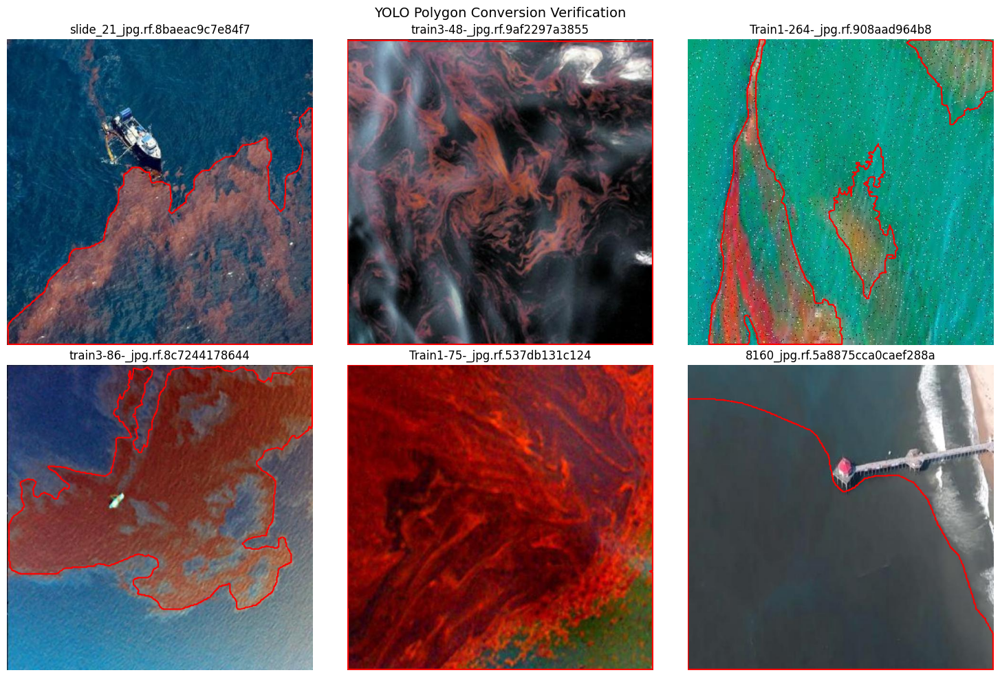

In [21]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

split = "train"
split_dir = DATA_ROOT / split
label_dir = YOLO_ROOT / "labels" / split

image_files = [
    p for p in split_dir.iterdir()
    if p.is_file()
    and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    and not p.name.endswith("_mask.png")
]

random.seed(42)
samples = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, samples):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label_path = label_dir / f"{image_path.stem}.txt"

    if label_path.exists() and label_path.read_text().strip():

        h, w = image.shape[:2]

        for line in label_path.read_text().strip().splitlines():

            values = list(map(float, line.split()))

            # First value = class ID
            coords = np.array(values[1:]).reshape(-1, 2)

            coords[:, 0] *= w
            coords[:, 1] *= h

            polygon = coords.astype(np.int32)

            cv2.polylines(
                image,
                [polygon],
                isClosed=True,
                color=(255, 0, 0),
                thickness=2
            )

    ax.imshow(image)
    ax.set_title(image_path.name[:30])
    ax.axis("off")

plt.suptitle(
    "YOLO Polygon Conversion Verification",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Yolo data structure

In [26]:
from pathlib import Path
import shutil

YOLO_ROOT = Path("/content/PetroVision/data/lados_yolo")
SOURCE_ROOT = Path("/content/PetroVision/data/lados")

# Create required YOLO directories
for split in ["train", "val", "test"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)


# Source split -> YOLO split
splits = {
    "train": "train",
    "val": "valid",
    "test": "test",
}

for yolo_split, source_split in splits.items():

    source_dir = SOURCE_ROOT / source_split
    image_out = YOLO_ROOT / "images" / yolo_split
    label_out = YOLO_ROOT / "labels" / yolo_split

    # -------------------------
    # Copy images
    # -------------------------
    image_files = [
        p for p in source_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        and not p.name.endswith("_mask.png")
    ]

    for image_path in image_files:
        destination = image_out / image_path.name

        if not destination.exists():
            shutil.copy2(image_path, destination)

    # -------------------------
    # Copy labels
    # -------------------------
    source_label_dir = YOLO_ROOT / "labels" / source_split

    # For train/test, source and destination may already be the same directory
    if source_label_dir.exists():

        label_files = list(source_label_dir.glob("*.txt"))

        for label_path in label_files:
            destination = label_out / label_path.name

            # Don't copy a file onto itself
            if label_path.resolve() != destination.resolve():
                shutil.copy2(label_path, destination)

    print(
        f"{yolo_split}: "
        f"{len(image_files)} images | "
        f"{len(list(label_out.glob('*.txt')))} labels"
    )


# -------------------------
# Create data.yaml
# -------------------------
yaml_path = YOLO_ROOT / "data.yaml"

yaml_content = """path: /content/PetroVision/data/lados_yolo

train: images/train
val: images/val
test: images/test

names:
  0: petroleum
"""

yaml_path.write_text(yaml_content)

print("\nCreated:", yaml_path)
print("\n" + yaml_content)

train: 2370 images | 2370 labels
val: 675 images | 675 labels
test: 343 images | 343 labels

Created: /content/PetroVision/data/lados_yolo/data.yaml

path: /content/PetroVision/data/lados_yolo

train: images/train
val: images/val
test: images/test

names:
  0: petroleum



## Filled masks verification

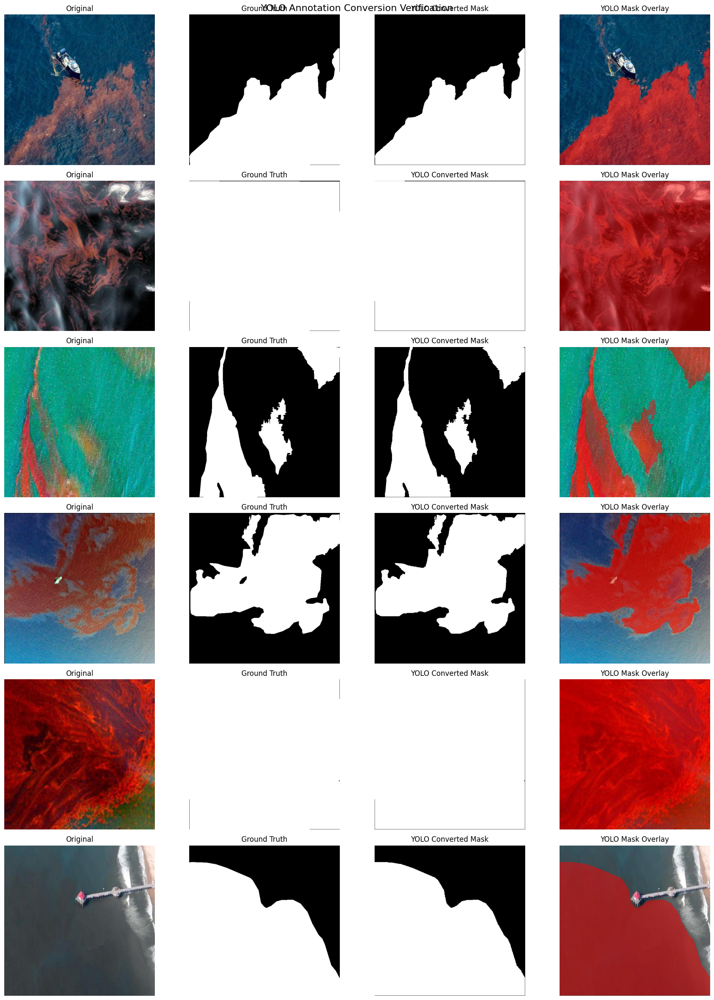

In [23]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

split = "train"
split_dir = DATA_ROOT / split
label_dir = YOLO_ROOT / "labels" / split

image_files = [
    p for p in split_dir.iterdir()
    if p.is_file()
    and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    and not p.name.endswith("_mask.png")
]

random.seed(42)
samples = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(
    len(samples), 4,
    figsize=(18, 4 * len(samples))
)

if len(samples) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, image_path in enumerate(samples):

    # -------------------------
    # Original image
    # -------------------------
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    # -------------------------
    # Ground truth mask
    # -------------------------
    mask_path = split_dir / f"{image_path.stem}_mask.png"

    original_mask = np.array(
        cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    )

    ground_truth = np.isin(
        original_mask,
        [1, 2, 4]       # Emulsion, Oil, Sheen
    ).astype(np.uint8)

    # -------------------------
    # YOLO reconstructed mask
    # -------------------------
    predicted_mask = np.zeros(
        (h, w),
        dtype=np.uint8
    )

    label_path = label_dir / f"{image_path.stem}.txt"

    if label_path.exists() and label_path.read_text().strip():

        for line in label_path.read_text().strip().splitlines():

            values = list(map(float, line.split()))

            coords = np.array(
                values[1:]
            ).reshape(-1, 2)

            coords[:, 0] *= w
            coords[:, 1] *= h

            polygon = coords.astype(np.int32)

            cv2.fillPoly(
                predicted_mask,
                [polygon],
                1
            )

    # -------------------------
    # Overlay
    # -------------------------
    overlay = image.copy()

    petroleum_pixels = predicted_mask.astype(bool)

    overlay[petroleum_pixels] = (
        0.5 * overlay[petroleum_pixels]
        + 0.5 * np.array([255, 0, 0])
    ).astype(np.uint8)

    # -------------------------
    # Display
    # -------------------------
    axes[row, 0].imshow(image)
    axes[row, 0].set_title("Original")

    axes[row, 1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 1].set_title("Ground Truth")

    axes[row, 2].imshow(
        predicted_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 2].set_title("YOLO Converted Mask")

    axes[row, 3].imshow(overlay)
    axes[row, 3].set_title("YOLO Mask Overlay")

    for ax in axes[row]:
        ax.axis("off")

plt.suptitle(
    "YOLO Annotation Conversion Verification",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [27]:
from pathlib import Path

YOLO_ROOT = Path("/content/PetroVision/data/lados_yolo")

expected_counts = {
    "train": 2370,
    "val": 675,
    "test": 343,
}

for split, expected in expected_counts.items():

    image_dir = YOLO_ROOT / "images" / split
    label_dir = YOLO_ROOT / "labels" / split

    images = [
        p for p in image_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    labels = list(label_dir.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    missing_labels = image_stems - label_stems
    extra_labels = label_stems - image_stems

    print(f"\n{split.upper()}")
    print(f"Images : {len(images)}")
    print(f"Labels : {len(labels)}")
    print(f"Expected images: {expected}")
    print(f"Missing labels : {len(missing_labels)}")
    print(f"Extra labels   : {len(extra_labels)}")

    if missing_labels:
        print("Example missing:", list(missing_labels)[:5])

    if extra_labels:
        print("Example extra:", list(extra_labels)[:5])

# Check data.yaml
yaml_path = YOLO_ROOT / "data.yaml"

print("\nDATA.YAML EXISTS:", yaml_path.exists())

if yaml_path.exists():
    print("\n--- data.yaml ---")
    print(yaml_path.read_text())

print("\nYOLO dataset integrity check completed.")


TRAIN
Images : 2370
Labels : 2370
Expected images: 2370
Missing labels : 0
Extra labels   : 0

VAL
Images : 675
Labels : 675
Expected images: 675
Missing labels : 0
Extra labels   : 0

TEST
Images : 343
Labels : 343
Expected images: 343
Missing labels : 0
Extra labels   : 0

DATA.YAML EXISTS: True

--- data.yaml ---
path: /content/PetroVision/data/lados_yolo

train: images/train
val: images/val
test: images/test

names:
  0: petroleum


YOLO dataset integrity check completed.


## Load YOLO11n-Seg

In [28]:
from ultralytics import YOLO
import torch
from pathlib import Path

# Experiment
EXPERIMENT_ID = "CV-YOLO-001"

# Paths
YOLO_ROOT = Path("/content/PetroVision/data/lados_yolo")
DATA_YAML = YOLO_ROOT / "data.yaml"

# Device
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Ultralytics:", __import__("ultralytics").__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Load pretrained YOLO11 nano segmentation model
MODEL_NAME = "yolo11n-seg.pt"

model = YOLO(MODEL_NAME)

print("\nModel loaded:", MODEL_NAME)
print("Task:", model.task)
print("Dataset config:", DATA_YAML)
print("Device:", DEVICE)

# Model information
model.info()

Ultralytics: 8.4.171
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4

Model loaded: yolo11n-seg.pt
Task: segment
Dataset config: /content/PetroVision/data/lados_yolo/data.yaml
Device: 0
YOLO11n-seg summary: 203 layers, 2,876,848 parameters, 0 gradients, 10.0 GFLOPs


(203, 2876848, 0, 9.9593344)

## Pre-training prediction sanity check

Testing images:
 - 515s5_jpeg_jpg.rf.b8631d57d76fe76c39d6486431c9da9b.jpg
 - o29_2346_jpg.rf.c19db9d8680273cf09e3b461ec3de6f8.jpg
 - 116791527_673230759936707_1908557071451096224_n_jpg.rf.9a716e461ec1b6fd13d42eb8f1e6992f.jpg
 - img-50-_jpg.rf.e5eb67a28a186dd4f6a5b886620c0954.jpg

Prediction completed.
Number of results: 4
Image 1: detections=2, masks=2
Image 2: detections=3, masks=3
Image 3: detections=1, masks=1
Image 4: detections=0, masks=0


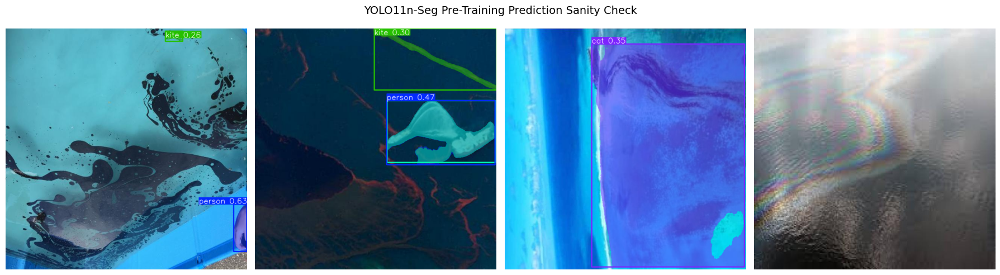

In [29]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt

# Load pretrained model
model = YOLO("yolo11n-seg.pt")

# Test images
test_dir = Path("/content/PetroVision/data/lados_yolo/images/test")

image_files = [
    p for p in test_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

random.seed(42)
samples = random.sample(image_files, min(4, len(image_files)))

print("Testing images:")
for p in samples:
    print(" -", p.name)

# Run inference
results = model.predict(
    source=[str(p) for p in samples],
    device=0,
    imgsz=640,
    conf=0.25,
    verbose=False
)

print("\nPrediction completed.")
print("Number of results:", len(results))

for i, result in enumerate(results):
    num_detections = (
        len(result.boxes)
        if result.boxes is not None
        else 0
    )

    num_masks = (
        len(result.masks)
        if result.masks is not None
        else 0
    )

    print(
        f"Image {i+1}: "
        f"detections={num_detections}, "
        f"masks={num_masks}"
    )

# Display predictions
fig, axes = plt.subplots(
    1,
    len(results),
    figsize=(18, 5)
)

if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):

    plotted = result.plot()

    ax.imshow(
        plotted[:, :, ::-1]
    )

    ax.axis("off")

plt.suptitle(
    "YOLO11n-Seg Pre-Training Prediction Sanity Check",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Training


| Setting            | Value                        |
| ------------------ | ---------------------------- |
| Model              | YOLO11n-Seg                  |
| Initialization     | Pretrained                   |
| Dataset            | LADOS                        |
| Task               | Instance segmentation        |
| Classes            | 1 — petroleum                |
| Image size         | 640                          |
| Batch              | 16                           |
| Epochs             | 20                           |
| Optimizer          | Ultralytics default          |
| Device             | Tesla T4                     |
| Pretrained weights | Yes                          |
| Validation         | LADOS validation split       |
| Test               | **Not used during training** |



Important: YOLO11-seg is an instance-segmentation model, unlike our semantic-segmentation U-Net/DeepLab/SegFormer experiments. We'll keep that distinction in the paper.


In [30]:
from ultralytics import YOLO
from pathlib import Path
import torch

# ============================================================
# CV-YOLO-001
# YOLO11n-Seg fine-tuning on LADOS
# ============================================================

EXPERIMENT_ID = "CV-YOLO-001"

YOLO_ROOT = Path("/content/PetroVision/data/lados_yolo")
DATA_YAML = YOLO_ROOT / "data.yaml"

MODEL_NAME = "yolo11n-seg.pt"

DEVICE = 0 if torch.cuda.is_available() else "cpu"

EPOCHS = 20
BATCH_SIZE = 16
IMAGE_SIZE = 640

PROJECT_DIR = "/content/drive/MyDrive/PetroVision/results"
RUN_NAME = "cv_yolo_001"

# Load pretrained YOLO11n-Seg
model = YOLO(MODEL_NAME)

print("Experiment:", EXPERIMENT_ID)
print("Model:", MODEL_NAME)
print("Dataset:", DATA_YAML)
print("Device:", DEVICE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Image size:", IMAGE_SIZE)

# Train
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=PROJECT_DIR,
    name=RUN_NAME,
    pretrained=True,
    save=True,
    plots=True,
    verbose=True
)

print("\nTraining completed.")
print("Results saved under:")
print(f"{PROJECT_DIR}/{RUN_NAME}")

Experiment: CV-YOLO-001
Model: yolo11n-seg.pt
Dataset: /content/PetroVision/data/lados_yolo/data.yaml
Device: 0
Epochs: 20
Batch size: 16
Image size: 640
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PetroVision/data/lados_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_r

## Test-set evaluation

In [31]:
from ultralytics import YOLO
from pathlib import Path
import torch
import json

# --------------------------------------------------
# CV-YOLO-001 — Test Set Evaluation
# --------------------------------------------------

EXPERIMENT_ID = "CV-YOLO-001"

MODEL_PATH = Path(
    "/content/drive/MyDrive/PetroVision/results/"
    "cv_yolo_001/weights/best.pt"
)

DATA_YAML = Path(
    "/content/PetroVision/data/lados_yolo/data.yaml"
)

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

DEVICE = 0 if torch.cuda.is_available() else "cpu"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

if not DATA_YAML.exists():
    raise FileNotFoundError(f"Dataset YAML not found: {DATA_YAML}")

model = YOLO(str(MODEL_PATH))

print("Experiment :", EXPERIMENT_ID)
print("Model      :", MODEL_PATH)
print("Test split :", "test")
print("Device     :", DEVICE)

test_results = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=DEVICE,
    plots=True,
    verbose=True
)

print("\nTest evaluation completed.")

Experiment : CV-YOLO-001
Model      : /content/drive/MyDrive/PetroVision/results/cv_yolo_001/weights/best.pt
Test split : test
Device     : 0
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1064.8±410.0 MB/s, size: 40.4 KB)
val: Scanning /content/PetroVision/data/lados_yolo/labels/test... 343 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 343/343 900.6it/s 0.4s
val: New cache created: /content/PetroVision/data/lados_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.5it/s 8.8s
                   all        343        454      0.831      0.725       0.78      0.592      0.801        0.7      0.736      0.459
Speed: 2.9ms preprocess, 6.8ms inference, 0.0ms loss, 3.5ms postprocess per

In [32]:
from pathlib import Path
import json

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

test_metrics = {
    "experiment_id": "CV-YOLO-001",
    "model": "YOLO11n-Seg",
    "model_checkpoint": "best.pt",
    "dataset": "LADOS",
    "test_images": 343,
    "test_instances": 454,

    "box_precision": 0.831,
    "box_recall": 0.725,
    "box_mAP50": 0.780,
    "box_mAP50_95": 0.592,

    "mask_precision": 0.801,
    "mask_recall": 0.700,
    "mask_mAP50": 0.736,
    "mask_mAP50_95": 0.459,

    "preprocess_ms_per_image": 2.9,
    "inference_ms_per_image": 6.8,
    "postprocess_ms_per_image": 3.5,
}

OUTPUT_PATH = RESULTS_DIR / "test_metrics_native.json"

with open(OUTPUT_PATH, "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Saved:", OUTPUT_PATH)

Saved: /content/drive/MyDrive/PetroVision/results/cv_yolo_001/test_metrics_native.json


## Derive pixel-level metrics from YOLO masks

In [33]:
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import numpy as np
import torch
import json
import cv2

# --------------------------------------------------
# CV-YOLO-001 — Pixel-Level Test Evaluation
# --------------------------------------------------

MODEL_PATH = Path(
    "/content/drive/MyDrive/PetroVision/results/"
    "cv_yolo_001/weights/best.pt"
)

IMAGE_DIR = Path("/content/PetroVision/data/lados/test")
RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

PETROLEUM_IDS = {1, 2, 4}

DEVICE = 0 if torch.cuda.is_available() else "cpu"

model = YOLO(str(MODEL_PATH))

image_files = sorted([
    p for p in IMAGE_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    and not p.name.endswith("_mask.png")
])

print("Test images:", len(image_files))

tp = fp = fn = tn = 0

for i, image_path in enumerate(image_files):

    # Corresponding LADOS ground-truth mask
    mask_path = IMAGE_DIR / f"{image_path.stem}_mask.png"

    if not mask_path.exists():
        raise FileNotFoundError(
            f"Ground-truth mask not found for {image_path.name}"
        )

    gt_mask = np.array(Image.open(mask_path))

    # Binary petroleum ground truth
    gt_binary = np.isin(
        gt_mask,
        list(PETROLEUM_IDS)
    )

    # YOLO prediction
    result = model.predict(
        source=str(image_path),
        imgsz=640,
        device=DEVICE,
        verbose=False,
        retina_masks=True
    )[0]

    pred_binary = np.zeros_like(gt_binary, dtype=bool)

    if result.masks is not None and len(result.masks.data) > 0:

        # YOLO masks are returned at prediction resolution.
        # Combine all predicted petroleum instances.
        masks = result.masks.data.detach().cpu().numpy()

        combined = np.any(masks > 0.5, axis=0).astype(np.uint8)

        # Resize prediction to original GT resolution
        pred_binary = cv2.resize(
            combined,
            (gt_binary.shape[1], gt_binary.shape[0]),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool)

    # Pixel-level confusion counts
    tp += np.logical_and(pred_binary, gt_binary).sum()
    fp += np.logical_and(pred_binary, ~gt_binary).sum()
    fn += np.logical_and(~pred_binary, gt_binary).sum()
    tn += np.logical_and(~pred_binary, ~gt_binary).sum()

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(image_files)}")

# --------------------------------------------------
# Metrics
# --------------------------------------------------

eps = 1e-8

iou = tp / (tp + fp + fn + eps)

dice = (2 * tp) / (
    2 * tp + fp + fn + eps
)

precision = tp / (
    tp + fp + eps
)

recall = tp / (
    tp + fn + eps
)

accuracy = (tp + tn) / (
    tp + tn + fp + fn + eps
)

pixel_metrics = {
    "experiment_id": "CV-YOLO-001",
    "evaluation": "Derived pixel-level evaluation",
    "dataset": "LADOS",
    "test_images": len(image_files),

    "IoU": float(iou),
    "Dice": float(dice),
    "Precision": float(precision),
    "Recall": float(recall),
    "Accuracy": float(accuracy),

    "TP": int(tp),
    "FP": int(fp),
    "FN": int(fn),
    "TN": int(tn)
}

output_path = RESULTS_DIR / "test_metrics_pixel_level.json"

with open(output_path, "w") as f:
    json.dump(pixel_metrics, f, indent=2)

print("\nPixel-level evaluation completed.")
print(json.dumps(pixel_metrics, indent=2))
print("\nSaved:", output_path)

Test images: 343
Processed 50/343
Processed 100/343
Processed 150/343
Processed 200/343
Processed 250/343
Processed 300/343

Pixel-level evaluation completed.
{
  "experiment_id": "CV-YOLO-001",
  "evaluation": "Derived pixel-level evaluation",
  "dataset": "LADOS",
  "test_images": 343,
  "IoU": 0.7511269745715169,
  "Dice": 0.8578783668789183,
  "Precision": 0.8099251757221116,
  "Recall": 0.9118672354325333,
  "Accuracy": 0.8428654833304268,
  "TP": 64048516,
  "FP": 15031031,
  "FN": 6190345,
  "TN": 49782396
}

Saved: /content/drive/MyDrive/PetroVision/results/cv_yolo_001/test_metrics_pixel_level.json


In [34]:
from pathlib import Path
import json
import pandas as pd

RESULTS_DIR = Path("/content/drive/MyDrive/PetroVision/results/cv_yolo_001")
SUMMARY_PATH = RESULTS_DIR / "experiment_summary.json"

# Load saved metrics
native_path = RESULTS_DIR / "test_metrics_native.json"
pixel_path = RESULTS_DIR / "test_metrics_pixel_level.json"

native_metrics = json.loads(native_path.read_text()) if native_path.exists() else {}
pixel_metrics = json.loads(pixel_path.read_text()) if pixel_path.exists() else {}

# Read actual training history saved by Ultralytics
history_path = RESULTS_DIR / "results.csv"
history_df = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame()

# Determine best training epoch from validation mask mAP50-95
best_epoch = None
best_mask_map5095 = None

if not history_df.empty:
    metric_col = "metrics/mask(mAP50-95)"
    if metric_col in history_df.columns:
        best_idx = history_df[metric_col].idxmax()
        best_epoch = int(history_df.loc[best_idx, "epoch"]) + 1
        best_mask_map5095 = float(history_df.loc[best_idx, metric_col])

summary = {
    "experiment_id": "CV-YOLO-001",
    "purpose": "Evaluate YOLO-based segmentation on the LADOS petroleum-contamination task",

    "dataset": {
        "name": "LADOS",
        "task": "Binary petroleum segmentation",
        "petroleum_classes": ["Oil", "Emulsion", "Sheen"],
        "train_images": 2370,
        "validation_images": 675,
        "test_images": 343
    },

    "model": {
        "architecture": "YOLO11n-Seg",
        "initialization": "Pretrained YOLO11n-Seg",
        "task": "Instance segmentation",
        "num_classes": 1,
        "class_name": "petroleum"
    },

    "training": {
        "epochs": 20,
        "image_size": 640,
        "batch_size": 16,
        "optimizer": "AdamW (Ultralytics auto-selected)",
        "best_epoch": best_epoch,
        "best_validation_mask_map50_95": best_mask_map5095
    },

    "native_yolo_test_metrics": native_metrics,

    "derived_pixel_level_metrics": pixel_metrics,

    "checkpoint": str(
        RESULTS_DIR / "weights" / "best.pt"
    ),

    "limitations": [
        "Native YOLO metrics and derived pixel-level metrics represent different evaluation protocols.",
        "Derived pixel-level evaluation combines all predicted petroleum instances into one binary mask.",
        "Results are specific to the evaluated LADOS dataset and training configuration.",
        "The RGB model detects visible petroleum-like regions and does not chemically identify petroleum type."
    ]
}

SUMMARY_PATH.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8"
)

print(f"Saved: {SUMMARY_PATH}")
print(json.dumps(summary, indent=2))

Saved: /content/drive/MyDrive/PetroVision/results/cv_yolo_001/experiment_summary.json
{
  "experiment_id": "CV-YOLO-001",
  "purpose": "Evaluate YOLO-based segmentation on the LADOS petroleum-contamination task",
  "dataset": {
    "name": "LADOS",
    "task": "Binary petroleum segmentation",
    "petroleum_classes": [
      "Oil",
      "Emulsion",
      "Sheen"
    ],
    "train_images": 2370,
    "validation_images": 675,
    "test_images": 343
  },
  "model": {
    "architecture": "YOLO11n-Seg",
    "initialization": "Pretrained YOLO11n-Seg",
    "task": "Instance segmentation",
    "num_classes": 1,
    "class_name": "petroleum"
  },
  "training": {
    "epochs": 20,
    "image_size": 640,
    "batch_size": 16,
    "optimizer": "AdamW (Ultralytics auto-selected)",
    "best_epoch": null,
    "best_validation_mask_map50_95": null
  },
  "native_yolo_test_metrics": {
    "experiment_id": "CV-YOLO-001",
    "model": "YOLO11n-Seg",
    "model_checkpoint": "best.pt",
    "dataset": "LA

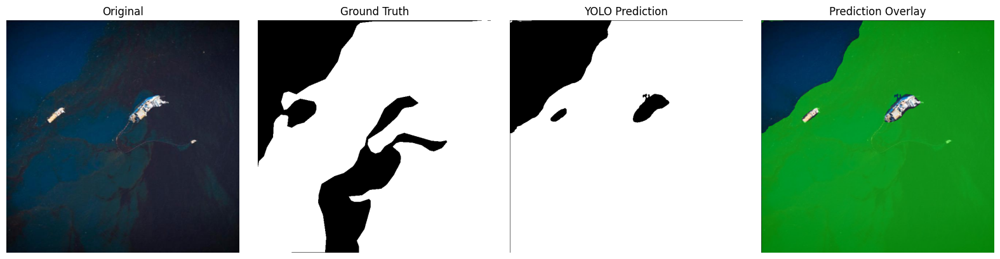

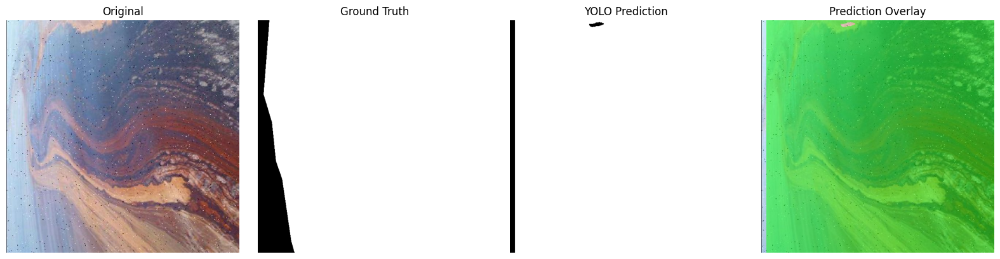

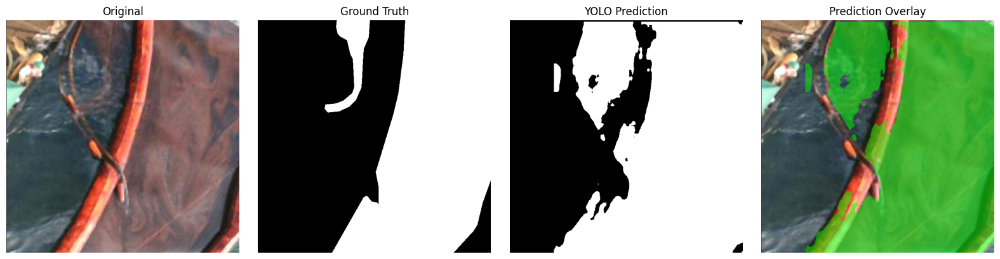

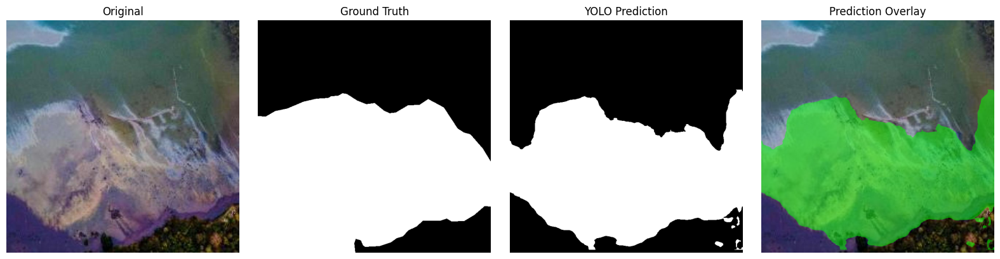

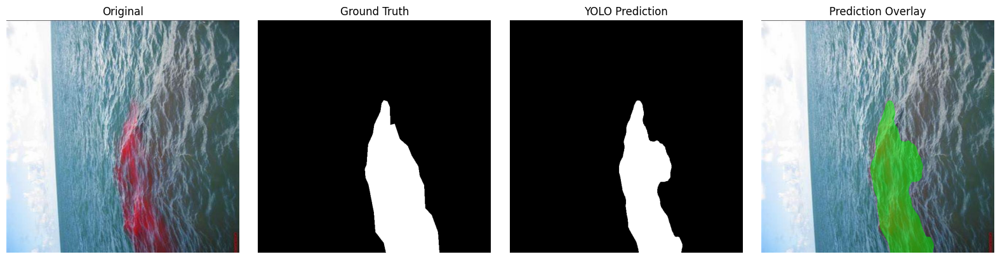

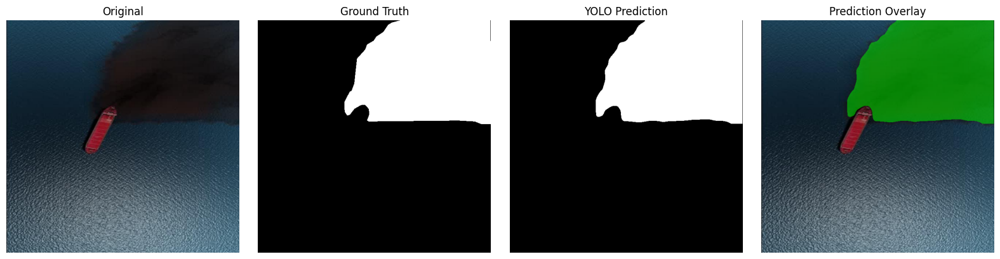


Saved visualizations to:
/content/drive/MyDrive/PetroVision/results/cv_yolo_001/visualizations


In [35]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Paths
YOLO_MODEL = "/content/drive/MyDrive/PetroVision/results/cv_yolo_001/weights/best.pt"
TEST_DIR = Path("/content/PetroVision/data/lados/test")

# Load trained YOLO model
model = YOLO(YOLO_MODEL)

# Find test images
image_paths = sorted([
    p for p in TEST_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    and "_mask" not in p.stem
])

# Select fixed test examples
selected_indices = [0, 50, 100, 150, 200, 300]
selected_paths = [image_paths[i] for i in selected_indices]

PETROLEUM_IDS = {1, 2, 4}

output_dir = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001/visualizations"
)
output_dir.mkdir(parents=True, exist_ok=True)

for idx, image_path in zip(selected_indices, selected_paths):

    # -------------------------
    # Load image
    # -------------------------
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # -------------------------
    # Ground-truth mask
    # -------------------------
    mask_path = image_path.with_name(
        image_path.stem + "_mask.png"
    )

    gt_mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    gt_binary = np.isin(
        gt_mask,
        list(PETROLEUM_IDS)
    )

    # -------------------------
    # YOLO prediction
    # -------------------------
    result = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        retina_masks=True,
        verbose=False
    )[0]

    pred_binary = np.zeros(
        gt_binary.shape,
        dtype=bool
    )

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        for mask in masks:

            mask_resized = cv2.resize(
                mask,
                (gt_binary.shape[1], gt_binary.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

            pred_binary |= mask_resized > 0.5

    # -------------------------
    # Ground truth overlay
    # -------------------------
    gt_overlay = image_rgb.copy()
    gt_overlay[gt_binary] = (
        0.5 * gt_overlay[gt_binary]
        + 0.5 * np.array([255, 0, 0])
    ).astype(np.uint8)

    # -------------------------
    # Prediction overlay
    # -------------------------
    pred_overlay = image_rgb.copy()
    pred_overlay[pred_binary] = (
        0.5 * pred_overlay[pred_binary]
        + 0.5 * np.array([0, 255, 0])
    ).astype(np.uint8)

    # -------------------------
    # Plot
    # -------------------------
    fig, axes = plt.subplots(
        1, 4,
        figsize=(16, 4)
    )

    axes[0].imshow(image_rgb)
    axes[0].set_title("Original")

    axes[1].imshow(gt_binary, cmap="gray")
    axes[1].set_title("Ground Truth")

    axes[2].imshow(pred_binary, cmap="gray")
    axes[2].set_title("YOLO Prediction")

    axes[3].imshow(pred_overlay)
    axes[3].set_title("Prediction Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()

    save_path = output_dir / f"yolo_test_{idx:03d}.png"

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print(f"\nSaved visualizations to:")
print(output_dir)

In [36]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO

# --------------------------------------------------
# Paths
# --------------------------------------------------
YOLO_MODEL = "/content/drive/MyDrive/PetroVision/results/cv_yolo_001/weights/best.pt"
TEST_DIR = Path("/content/PetroVision/data/lados/test")

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

PER_IMAGE_PATH = RESULTS_DIR / "per_image_pixel_iou.csv"

# --------------------------------------------------
# Load model
# --------------------------------------------------
model = YOLO(YOLO_MODEL)

PETROLEUM_IDS = {1, 2, 4}

image_paths = sorted([
    p for p in TEST_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    and "_mask" not in p.stem
])

print(f"Test images found: {len(image_paths)}")

# --------------------------------------------------
# Evaluate every test image
# --------------------------------------------------
records = []

for count, image_path in enumerate(image_paths, start=1):

    # Ground truth
    mask_path = image_path.with_name(
        image_path.stem + "_mask.png"
    )

    gt_mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    gt_binary = np.isin(
        gt_mask,
        list(PETROLEUM_IDS)
    )

    # YOLO prediction
    result = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        retina_masks=True,
        verbose=False
    )[0]

    pred_binary = np.zeros(
        gt_binary.shape,
        dtype=bool
    )

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        for mask in masks:

            mask_resized = cv2.resize(
                mask,
                (gt_binary.shape[1], gt_binary.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

            pred_binary |= mask_resized > 0.5

    # Pixel-level confusion
    tp = np.logical_and(
        pred_binary,
        gt_binary
    ).sum()

    fp = np.logical_and(
        pred_binary,
        ~gt_binary
    ).sum()

    fn = np.logical_and(
        ~pred_binary,
        gt_binary
    ).sum()

    union = tp + fp + fn

    # IoU
    if union > 0:
        iou = tp / union
    else:
        # Both prediction and GT are empty
        iou = 1.0

    records.append({
        "image": image_path.name,
        "IoU": float(iou),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "ground_truth_petroleum_pixels": int(gt_binary.sum()),
        "predicted_petroleum_pixels": int(pred_binary.sum())
    })

    if count % 25 == 0:
        print(f"Processed {count}/{len(image_paths)}")

# --------------------------------------------------
# Create DataFrame
# --------------------------------------------------
iou_df = pd.DataFrame(records)

iou_df = iou_df.sort_values(
    "IoU",
    ascending=False
).reset_index(drop=True)

# Save complete per-image results
iou_df.to_csv(
    PER_IMAGE_PATH,
    index=False
)

# --------------------------------------------------
# Best / Worst / Typical
# --------------------------------------------------
best_5 = iou_df.head(5)

worst_5 = iou_df.tail(5).sort_values(
    "IoU",
    ascending=True
)

median_iou = iou_df["IoU"].median()

iou_df["distance_from_median"] = (
    iou_df["IoU"] - median_iou
).abs()

typical_5 = (
    iou_df
    .sort_values("distance_from_median")
    .head(5)
)

# --------------------------------------------------
# Display
# --------------------------------------------------
print("\n" + "=" * 60)
print("BEST 5")
print("=" * 60)
display(
    best_5[
        ["image", "IoU",
         "ground_truth_petroleum_pixels",
         "predicted_petroleum_pixels"]
    ].style.format({
        "IoU": "{:.4f}"
    })
)

print("\n" + "=" * 60)
print("WORST 5")
print("=" * 60)
display(
    worst_5[
        ["image", "IoU",
         "ground_truth_petroleum_pixels",
         "predicted_petroleum_pixels"]
    ].style.format({
        "IoU": "{:.4f}"
    })
)

print("\n" + "=" * 60)
print("TYPICAL 5")
print("=" * 60)
display(
    typical_5[
        ["image", "IoU",
         "ground_truth_petroleum_pixels",
         "predicted_petroleum_pixels"]
    ].style.format({
        "IoU": "{:.4f}"
    })
)

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"Images evaluated : {len(iou_df)}")
print(f"Mean IoU         : {iou_df['IoU'].mean():.6f}")
print(f"Median IoU       : {iou_df['IoU'].median():.6f}")
print(f"Minimum IoU      : {iou_df['IoU'].min():.6f}")
print(f"Maximum IoU      : {iou_df['IoU'].max():.6f}")

print(f"\nSaved to:")
print(PER_IMAGE_PATH)

Test images found: 343
Processed 25/343
Processed 50/343
Processed 75/343
Processed 100/343
Processed 125/343
Processed 150/343
Processed 175/343
Processed 200/343
Processed 225/343
Processed 250/343
Processed 275/343
Processed 300/343
Processed 325/343

BEST 5


,image,IoU,ground_truth_petroleum_pixels,predicted_petroleum_pixels
0,Oil-Pollution_original_oil-25-jpg_bca35ee1-363d-4366-98b4-2b162757f6b0_jpg.rf.55a0aeaa39617400ca4024b647816ab2.jpg,1.0000,173056,173056
1,Oil-Pollution_original_oil-25-jpg_40d61c8d-abaa-4323-b643-b2629168b719_jpg.rf.4d2355e419da3c2030a0edfdb8b43cce.jpg,1.0000,173056,173056
2,IMG20230604100545_01_jpg.rf.b4f8ff4481cf24ebf4969a78ec280750.jpg,0.9984,409600,408960
3,Oil-Pollution_original_oil-25-jpg_bca35ee1-363d-4366-98b4-2b162757f6b0_jpg.rf.a7fdc02387de832ef9d8fe1a8d61246d.jpg,0.9984,409600,408960
4,122_jpg.rf.5c2d1a98f8c3ea9c26faad42e3142089.jpg,0.9982,409600,408874



WORST 5


,image,IoU,ground_truth_petroleum_pixels,predicted_petroleum_pixels
338,78_jpg.rf.4d77302c4f842bddce34a41341072d1b.jpg,0.0000,0,403352
339,31_jpg.rf.e6639f0932d897e14a14811b21eec845.jpg,0.0000,61059,0
340,Oil-Pollution_original_oil-1-jpg_e676bc44-8c41-4586-ad96-8a07e167f8af_jpg.rf.c926bd9fadf276ad8dc2bf31d17c16a2.jpg,0.0000,26594,0
341,Train1-177-_jpg.rf.4bdae53753002c0eb32019fe0bf0b3ea.jpg,0.0000,409088,0
342,diesel_jpg.rf.7b65892653711f88bebdfc982a52ffd3.jpg,0.0000,29729,0



TYPICAL 5


,image,IoU,ground_truth_petroleum_pixels,predicted_petroleum_pixels
171,264_jpg.rf.e85cf8a7f930b94f6cbda14b4dab84df.jpg,0.8247,225088,247418
172,811_jpeg_jpg.rf.822c630918529dae8352ef9efbace7c4.jpg,0.8246,219722,217700
173,7512_jpg.rf.e52dd1e13c1582aa1f8df102dae2e66c.jpg,0.8231,156496,151731
170,samye-krupnye-razlivy-nefti-pohozhie-na-katastrofu-v-norilske-4_jpg.rf.df1c6b6a6f47d8390b816630dcc25750.jpg,0.8267,64992,69585
174,razliv-nefti-u-mavrikija_jpg.rf.ec8be3c4d6258791320858808990b09a.jpg,0.8226,97117,94023



SUMMARY
Images evaluated : 343
Mean IoU         : 0.736681
Median IoU       : 0.824665
Minimum IoU      : 0.000000
Maximum IoU      : 1.000000

Saved to:
/content/drive/MyDrive/PetroVision/results/cv_yolo_001/per_image_pixel_iou.csv


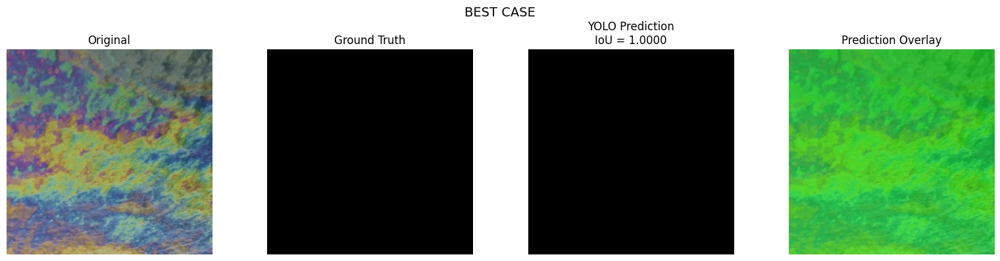

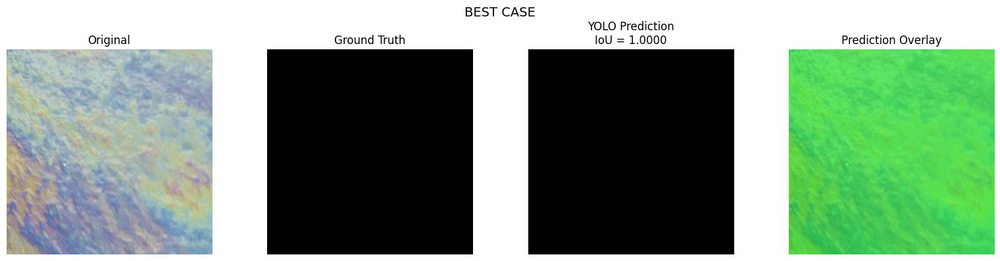

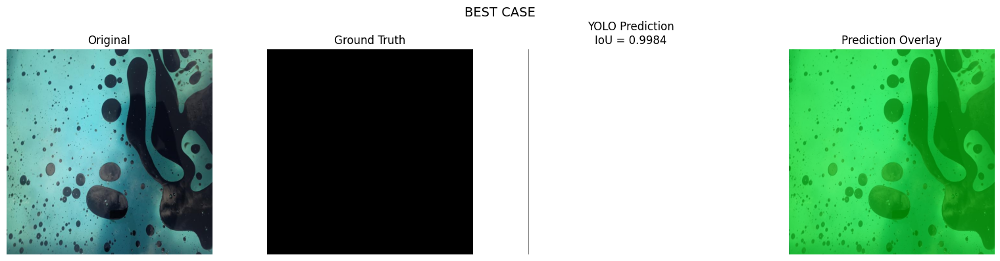

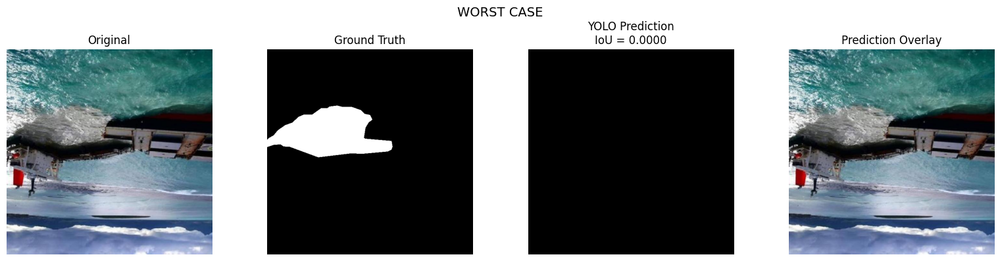

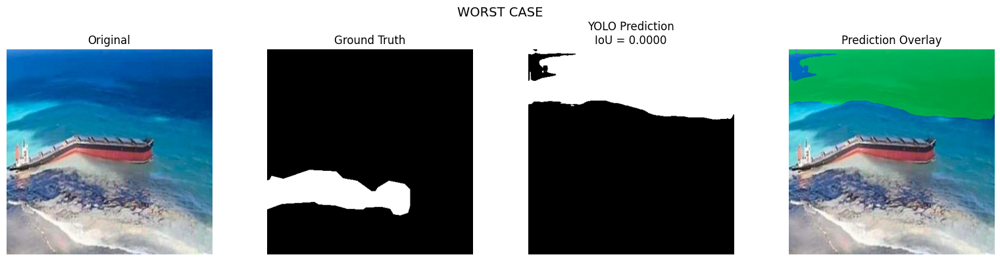

...

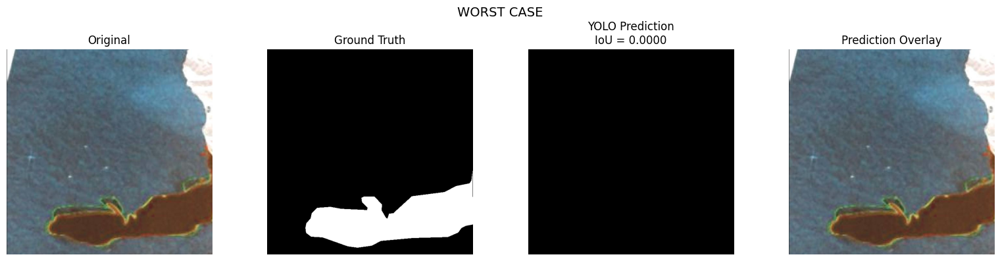

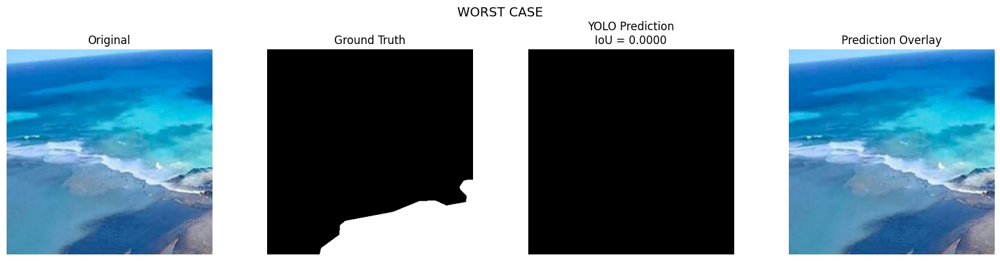

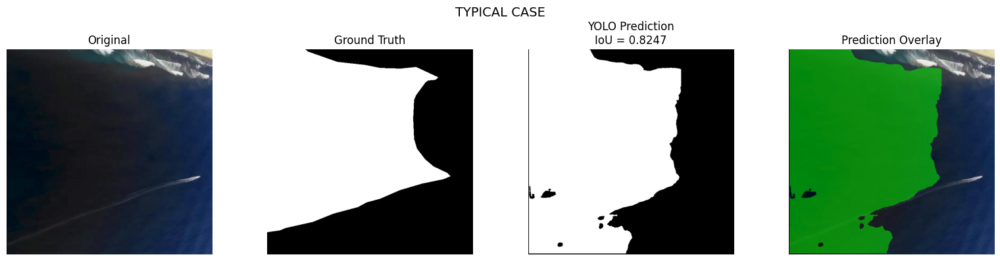

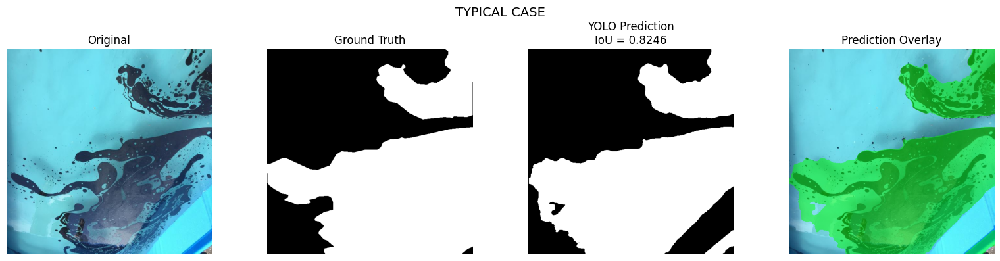

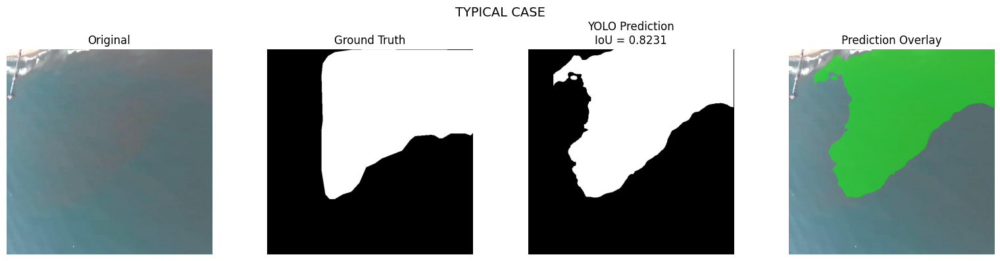


Saved selected-case visualizations to:
/content/drive/MyDrive/PetroVision/results/cv_yolo_001/selected_case_visualizations


In [37]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --------------------------------------------------
# Paths
# --------------------------------------------------
YOLO_MODEL = "/content/drive/MyDrive/PetroVision/results/cv_yolo_001/weights/best.pt"
TEST_DIR = Path("/content/PetroVision/data/lados/test")

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

IOU_CSV = RESULTS_DIR / "per_image_pixel_iou.csv"

VIS_DIR = RESULTS_DIR / "selected_case_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Load results and model
# --------------------------------------------------
iou_df = pd.read_csv(IOU_CSV)
model = YOLO(YOLO_MODEL)

PETROLEUM_IDS = {1, 2, 4}

# --------------------------------------------------
# Select cases
# --------------------------------------------------
best_cases = iou_df.nlargest(3, "IoU")

worst_cases = iou_df.nsmallest(5, "IoU")

median_iou = iou_df["IoU"].median()

typical_cases = (
    iou_df.assign(
        median_distance=lambda x:
        (x["IoU"] - median_iou).abs()
    )
    .nsmallest(3, "median_distance")
)

cases = [
    ("best", best_cases),
    ("worst", worst_cases),
    ("typical", typical_cases)
]

# --------------------------------------------------
# Visualization function
# --------------------------------------------------
def visualize_case(row, category):

    image_name = row["image"]
    image_path = TEST_DIR / image_name

    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Ground truth
    mask_path = image_path.with_name(
        image_path.stem + "_mask.png"
    )

    gt_mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    gt_binary = np.isin(
        gt_mask,
        list(PETROLEUM_IDS)
    )

    # YOLO prediction
    result = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        retina_masks=True,
        verbose=False
    )[0]

    pred_binary = np.zeros(
        gt_binary.shape,
        dtype=bool
    )

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        for mask in masks:

            mask_resized = cv2.resize(
                mask,
                (gt_binary.shape[1], gt_binary.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

            pred_binary |= mask_resized > 0.5

    # Prediction overlay
    overlay = image_rgb.copy()

    overlay[pred_binary] = (
        0.5 * overlay[pred_binary]
        + 0.5 * np.array([0, 255, 0])
    ).astype(np.uint8)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, axes = plt.subplots(
        1, 4,
        figsize=(16, 4)
    )

    axes[0].imshow(image_rgb)
    axes[0].set_title("Original")

    axes[1].imshow(gt_binary, cmap="gray")
    axes[1].set_title("Ground Truth")

    axes[2].imshow(pred_binary, cmap="gray")
    axes[2].set_title(
        f"YOLO Prediction\nIoU = {row['IoU']:.4f}"
    )

    axes[3].imshow(overlay)
    axes[3].set_title("Prediction Overlay")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{category.upper()} CASE",
        fontsize=14
    )

    plt.tight_layout()

    safe_name = (
        image_path.stem[:50]
        .replace(" ", "_")
        .replace("/", "_")
    )

    save_path = (
        VIS_DIR /
        f"{category}_iou_{row['IoU']:.4f}_{safe_name}.png"
    )

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# --------------------------------------------------
# Generate all selected visualizations
# --------------------------------------------------
for category, dataframe in cases:

    for _, row in dataframe.iterrows():

        visualize_case(
            row,
            category
        )

print("\nSaved selected-case visualizations to:")
print(VIS_DIR)

In [38]:
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

IOU_CSV = RESULTS_DIR / "per_image_pixel_iou.csv"

df = pd.read_csv(IOU_CSV)

# --------------------------------------------------
# Separate images by ground-truth petroleum presence
# --------------------------------------------------

petroleum_present = df[
    df["ground_truth_petroleum_pixels"] > 0
].copy()

no_petroleum = df[
    df["ground_truth_petroleum_pixels"] == 0
].copy()

# --------------------------------------------------
# Correct per-image IoU analysis
# --------------------------------------------------

print("=" * 60)
print("GROUND-TRUTH DATASET BREAKDOWN")
print("=" * 60)

print(f"Total test images       : {len(df)}")
print(f"Petroleum-present       : {len(petroleum_present)}")
print(f"No-petroleum            : {len(no_petroleum)}")

# --------------------------------------------------
# Petroleum-present images
# --------------------------------------------------

print("\n" + "=" * 60)
print("PETROLEUM-PRESENT IMAGES")
print("=" * 60)

print(
    f"Mean IoU   : {petroleum_present['IoU'].mean():.6f}"
)

print(
    f"Median IoU : {petroleum_present['IoU'].median():.6f}"
)

print(
    f"Minimum    : {petroleum_present['IoU'].min():.6f}"
)

print(
    f"Maximum    : {petroleum_present['IoU'].max():.6f}"
)

# --------------------------------------------------
# No-petroleum images
# --------------------------------------------------

# Prediction > 0 means false positive
false_positive_images = no_petroleum[
    no_petroleum["predicted_petroleum_pixels"] > 0
].copy()

correct_negative_images = no_petroleum[
    no_petroleum["predicted_petroleum_pixels"] == 0
].copy()

print("\n" + "=" * 60)
print("NO-PETROLEUM IMAGES")
print("=" * 60)

print(
    f"No-petroleum images     : {len(no_petroleum)}"
)

print(
    f"Correctly predicted 0  : {len(correct_negative_images)}"
)

print(
    f"False-positive images   : {len(false_positive_images)}"
)

if len(no_petroleum) > 0:
    false_positive_rate = (
        len(false_positive_images)
        / len(no_petroleum)
    )

    print(
        f"False-positive rate     : "
        f"{false_positive_rate:.6f}"
    )

# --------------------------------------------------
# Missed petroleum cases
# --------------------------------------------------

missed_petroleum = petroleum_present[
    petroleum_present["predicted_petroleum_pixels"] == 0
].copy()

print("\n" + "=" * 60)
print("MISSED PETROLEUM CASES")
print("=" * 60)

print(
    f"Petroleum-present images : {len(petroleum_present)}"
)

print(
    f"Completely missed        : {len(missed_petroleum)}"
)

if len(petroleum_present) > 0:
    miss_rate = (
        len(missed_petroleum)
        / len(petroleum_present)
    )

    print(
        f"Complete-miss rate       : "
        f"{miss_rate:.6f}"
    )

# --------------------------------------------------
# Save analysis
# --------------------------------------------------

analysis = {
    "total_test_images": int(len(df)),
    "petroleum_present_images": int(len(petroleum_present)),
    "no_petroleum_images": int(len(no_petroleum)),
    "correct_negative_images": int(len(correct_negative_images)),
    "false_positive_images": int(len(false_positive_images)),
    "false_positive_rate": (
        float(false_positive_rate)
        if len(no_petroleum) > 0 else None
    ),
    "completely_missed_petroleum_images": int(
        len(missed_petroleum)
    ),
    "complete_miss_rate": (
        float(miss_rate)
        if len(petroleum_present) > 0 else None
    ),
    "petroleum_present_mean_iou": float(
        petroleum_present["IoU"].mean()
    ),
    "petroleum_present_median_iou": float(
        petroleum_present["IoU"].median()
    ),
}

output_path = (
    RESULTS_DIR /
    "error_analysis_presence.json"
)

output_path.write_text(
    __import__("json").dumps(
        analysis,
        indent=2
    ),
    encoding="utf-8"
)

print("\nSaved:")
print(output_path)

GROUND-TRUTH DATASET BREAKDOWN
Total test images       : 343
Petroleum-present       : 342
No-petroleum            : 1

PETROLEUM-PRESENT IMAGES
Mean IoU   : 0.738835
Median IoU : 0.825697
Minimum    : 0.000000
Maximum    : 1.000000

NO-PETROLEUM IMAGES
No-petroleum images     : 1
Correctly predicted 0  : 0
False-positive images   : 1
False-positive rate     : 1.000000

MISSED PETROLEUM CASES
Petroleum-present images : 342
Completely missed        : 5
Complete-miss rate       : 0.014620

Saved:
/content/drive/MyDrive/PetroVision/results/cv_yolo_001/error_analysis_presence.json


In [39]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

df = pd.read_csv(
    RESULTS_DIR / "per_image_pixel_iou.csv"
)

missed = df[
    (df["ground_truth_petroleum_pixels"] > 0) &
    (df["predicted_petroleum_pixels"] == 0)
].copy()

print("=" * 70)
print("COMPLETELY MISSED PETROLEUM CASES")
print("=" * 70)

display(
    missed[
        [
            "image",
            "IoU",
            "ground_truth_petroleum_pixels",
            "predicted_petroleum_pixels"
        ]
    ]
)

print(f"\nTotal completely missed: {len(missed)}")

COMPLETELY MISSED PETROLEUM CASES


,image,IoU,ground_truth_petroleum_pixels,predicted_petroleum_pixels
336,117536352_223729965661888_4203326571010316604_...,0.0,38236,0
339,31_jpg.rf.e6639f0932d897e14a14811b21eec845.jpg,0.0,61059,0
340,Oil-Pollution_original_oil-1-jpg_e676bc44-8c41...,0.0,26594,0
341,Train1-177-_jpg.rf.4bdae53753002c0eb32019fe0bf...,0.0,409088,0
342,diesel_jpg.rf.7b65892653711f88bebdfc982a52ffd3...,0.0,29729,0



Total completely missed: 5


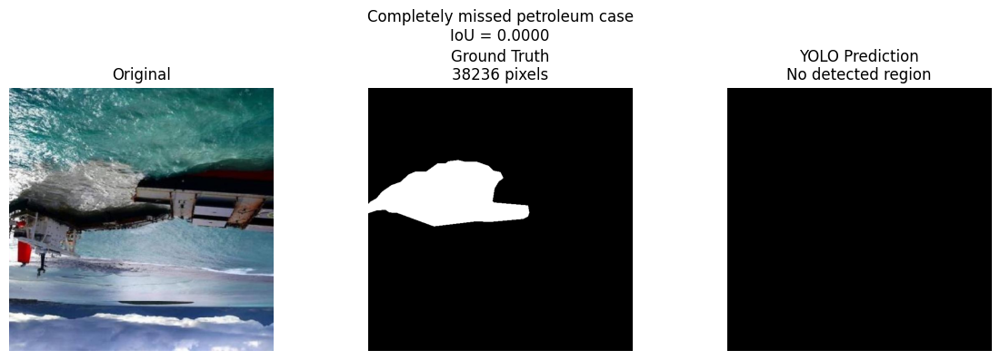

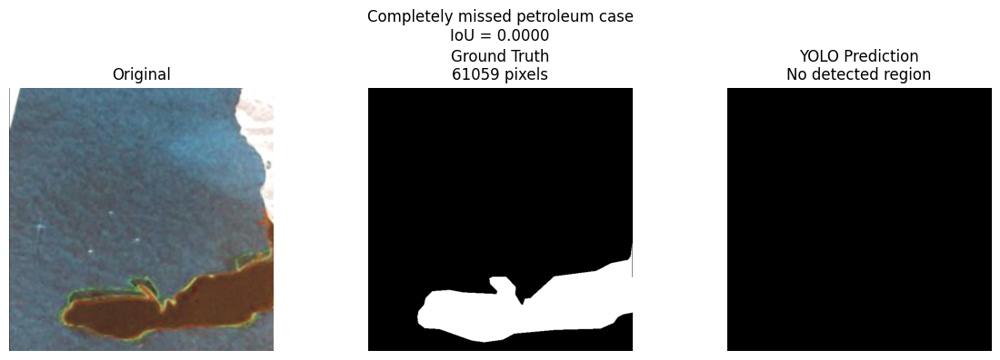

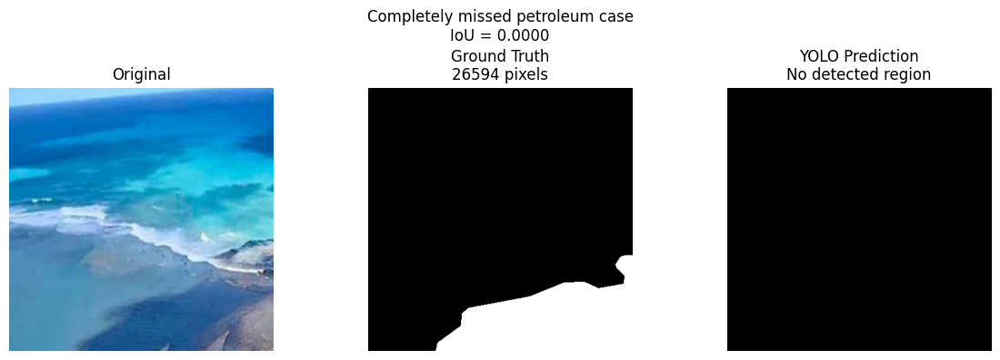

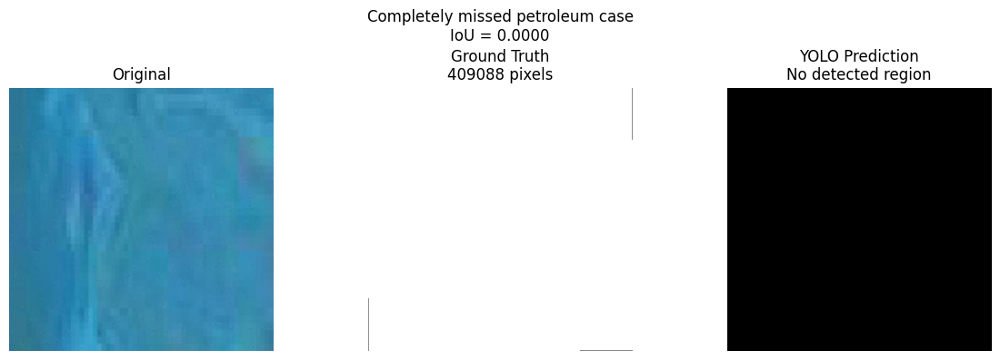

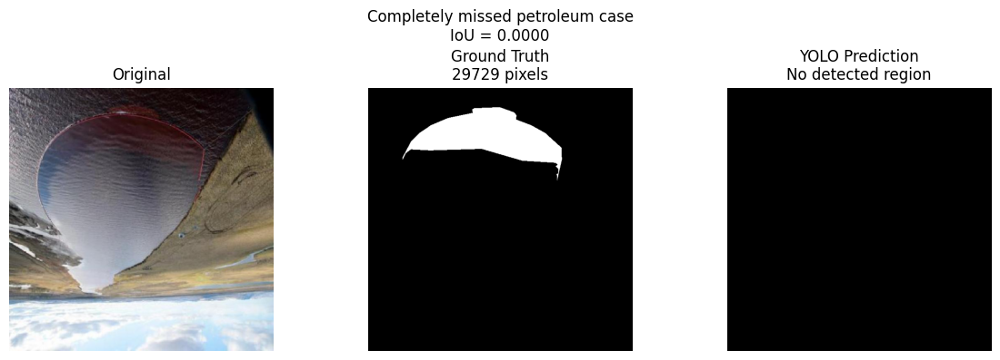

In [40]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

YOLO_MODEL = (
    "/content/drive/MyDrive/PetroVision/"
    "results/cv_yolo_001/weights/best.pt"
)

TEST_DIR = Path("/content/PetroVision/data/lados/test")

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

df = pd.read_csv(
    RESULTS_DIR / "per_image_pixel_iou.csv"
)

missed = df[
    (df["ground_truth_petroleum_pixels"] > 0) &
    (df["predicted_petroleum_pixels"] == 0)
]

model = YOLO(YOLO_MODEL)

PETROLEUM_IDS = {1, 2, 4}

for _, row in missed.iterrows():

    image_path = TEST_DIR / row["image"]

    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    mask_path = image_path.with_name(
        image_path.stem + "_mask.png"
    )

    gt_mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    gt_binary = np.isin(
        gt_mask,
        list(PETROLEUM_IDS)
    )

    result = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        retina_masks=True,
        verbose=False
    )[0]

    pred_binary = np.zeros(
        gt_binary.shape,
        dtype=bool
    )

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        for mask in masks:

            mask_resized = cv2.resize(
                mask,
                (gt_binary.shape[1], gt_binary.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

            pred_binary |= mask_resized > 0.5

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 4)
    )

    axes[0].imshow(image_rgb)
    axes[0].set_title("Original")

    axes[1].imshow(gt_binary, cmap="gray")
    axes[1].set_title(
        f"Ground Truth\n"
        f"{int(row['ground_truth_petroleum_pixels'])} pixels"
    )

    axes[2].imshow(pred_binary, cmap="gray")
    axes[2].set_title(
        "YOLO Prediction\nNo detected region"
    )

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"Completely missed petroleum case\n"
        f"IoU = {row['IoU']:.4f}"
    )

    plt.tight_layout()
    plt.show()
    plt.close()

In [41]:
from pathlib import Path
import json
import pandas as pd

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_yolo_001"
)

# Load actual per-image results
df = pd.read_csv(
    RESULTS_DIR / "per_image_pixel_iou.csv"
)

# --------------------------------------------------
# Dataset groups
# --------------------------------------------------

petroleum_present = df[
    df["ground_truth_petroleum_pixels"] > 0
]

no_petroleum = df[
    df["ground_truth_petroleum_pixels"] == 0
]

# Completely missed petroleum
missed = petroleum_present[
    petroleum_present["predicted_petroleum_pixels"] == 0
]

# False positive on no-petroleum images
false_positive = no_petroleum[
    no_petroleum["predicted_petroleum_pixels"] > 0
]

# --------------------------------------------------
# Summary
# --------------------------------------------------

summary = {
    "experiment_id": "CV-YOLO-001",

    "test_set": {
        "total_images": int(len(df)),
        "petroleum_present_images": int(len(petroleum_present)),
        "no_petroleum_images": int(len(no_petroleum))
    },

    "petroleum_present_analysis": {
        "mean_per_image_iou": float(
            petroleum_present["IoU"].mean()
        ),
        "median_per_image_iou": float(
            petroleum_present["IoU"].median()
        ),
        "minimum_per_image_iou": float(
            petroleum_present["IoU"].min()
        ),
        "maximum_per_image_iou": float(
            petroleum_present["IoU"].max()
        ),
        "complete_misses": int(len(missed)),
        "complete_miss_rate": float(
            len(missed) / len(petroleum_present)
        )
    },

    "no_petroleum_analysis": {
        "images": int(len(no_petroleum)),
        "false_positive_images": int(
            len(false_positive)
        ),
        "false_positive_rate": (
            float(len(false_positive) / len(no_petroleum))
            if len(no_petroleum) > 0
            else None
        )
    },

    "complete_miss_cases": [
        {
            "image": row["image"],
            "ground_truth_petroleum_pixels": int(
                row["ground_truth_petroleum_pixels"]
            ),
            "predicted_petroleum_pixels": int(
                row["predicted_petroleum_pixels"]
            ),
            "IoU": float(row["IoU"])
        }
        for _, row in missed.iterrows()
    ],

    "interpretation": {
        "validated_findings": [
            "The model completely missed 5 petroleum-present test images.",
            "The test set contained one image without annotated petroleum.",
            "The model produced a petroleum prediction on that no-petroleum image.",
            "Per-image IoU varies substantially across the test set."
        ],
        "unverified_causes": [
            "Visual causes of the complete misses require inspection of the corresponding images.",
            "No cause of failure is inferred from filenames alone."
        ]
    }
}

output_path = (
    RESULTS_DIR /
    "yolo_error_analysis_summary.json"
)

output_path.write_text(
    json.dumps(
        summary,
        indent=2
    ),
    encoding="utf-8"
)

print("Saved:")
print(output_path)

print("\nComplete misses:")
for case in summary["complete_miss_cases"]:
    print(
        f"- {case['image']}: "
        f"IoU={case['IoU']:.4f}, "
        f"GT pixels={case['ground_truth_petroleum_pixels']}"
    )

Saved:
/content/drive/MyDrive/PetroVision/results/cv_yolo_001/yolo_error_analysis_summary.json

Complete misses:
- 117536352_223729965661888_4203326571010316604_n_jpg.rf.22c6252d7ceb63deb12794d4e23a0534.jpg: IoU=0.0000, GT pixels=38236
- 31_jpg.rf.e6639f0932d897e14a14811b21eec845.jpg: IoU=0.0000, GT pixels=61059
- Oil-Pollution_original_oil-1-jpg_e676bc44-8c41-4586-ad96-8a07e167f8af_jpg.rf.c926bd9fadf276ad8dc2bf31d17c16a2.jpg: IoU=0.0000, GT pixels=26594
- Train1-177-_jpg.rf.4bdae53753002c0eb32019fe0bf0b3ea.jpg: IoU=0.0000, GT pixels=409088
- diesel_jpg.rf.7b65892653711f88bebdfc982a52ffd3.jpg: IoU=0.0000, GT pixels=29729


# Final CV model comparison

PETROVISION CV MODEL COMPARISON


,Model,IoU,Dice,Precision,Recall,Accuracy
0,U-Net,0.649758,0.787701,0.766569,0.810031,0.767513
1,DeepLabV3+,0.820109,0.901165,0.894639,0.907787,0.893977
2,SegFormer,0.814282,0.897636,0.901561,0.893745,0.891464
3,Mask2Former,0.802483,0.890419,0.841407,0.945496,0.876089
4,YOLO11n-Seg,0.751127,0.857878,0.809925,0.911867,0.842865



Saved:
/content/drive/MyDrive/PetroVision/results/cv_model_comparison.csv


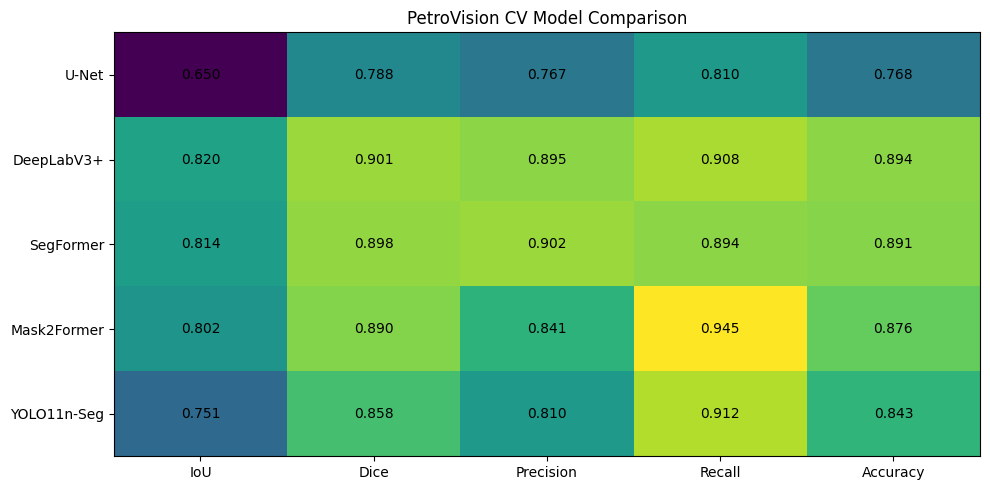


Saved:
/content/drive/MyDrive/PetroVision/results/cv_model_comparison_heatmap.png


In [45]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/PetroVision/results"
)

# --------------------------------------------------
# Metric file locations
# --------------------------------------------------

experiments = {
    "U-Net": RESULTS_ROOT / "cv_unet_001" / "test_metrics.json",

    "DeepLabV3+": (
        RESULTS_ROOT /
        "cv_deeplab_001" /
        "test_metrics.json"
    ),

    "SegFormer": (
        RESULTS_ROOT /
        "cv_segformer_001" /
        "test_metrics.json"
    ),

    "Mask2Former": (
        RESULTS_ROOT /
        "cv_mask2former_001" /
        "test_metrics.json"
    ),

    "YOLO11n-Seg": (
        RESULTS_ROOT /
        "cv_yolo_001" /
        "test_metrics_pixel_level.json"
    )
}

# --------------------------------------------------
# Load actual metrics
# --------------------------------------------------

records = []

for model_name, path in experiments.items():

    if not path.exists():
        print(f"WARNING: Missing file -> {path}")
        continue

    metrics = json.loads(
        path.read_text(encoding="utf-8")
    )

    records.append({
        "Model": model_name,
        "IoU": metrics["IoU"],
        "Dice": metrics["Dice"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "Accuracy": metrics["Accuracy"]
    })

comparison_df = pd.DataFrame(records)

# --------------------------------------------------
# Display numerical comparison
# --------------------------------------------------

print("=" * 80)
print("PETROVISION CV MODEL COMPARISON")
print("=" * 80)

display(
    comparison_df.style.format({
        "IoU": "{:.6f}",
        "Dice": "{:.6f}",
        "Precision": "{:.6f}",
        "Recall": "{:.6f}",
        "Accuracy": "{:.6f}"
    })
)

# --------------------------------------------------
# Save comparison table
# --------------------------------------------------

comparison_csv = (
    RESULTS_ROOT /
    "cv_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_csv,
    index=False
)

print("\nSaved:")
print(comparison_csv)

# --------------------------------------------------
# Create metric matrix
# --------------------------------------------------

metric_columns = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

matrix = comparison_df.set_index(
    "Model"
)[metric_columns]

# --------------------------------------------------
# Heatmap
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5)
)

im = ax.imshow(
    matrix.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(metric_columns))
)

ax.set_xticklabels(
    metric_columns
)

ax.set_yticks(
    np.arange(len(matrix.index))
)

ax.set_yticklabels(
    matrix.index
)

ax.set_title(
    "PetroVision CV Model Comparison"
)

# Add actual values
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):

        ax.text(
            j,
            i,
            f"{matrix.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

heatmap_path = (
    RESULTS_ROOT /
    "cv_model_comparison_heatmap.png"
)

plt.savefig(
    heatmap_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(heatmap_path)

## CV efficiency comparison

In [49]:
import pandas as pd
from pathlib import Path

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/PetroVision"
)

records = [
    {
        "Model": "U-Net",
        "Experiment": "CV-UNET-001",
        "Architecture": "Custom U-Net",
        "Type": "CNN",
        "Parameters": 1_942_577,
        "Inference_ms": None
    },
    {
        "Model": "DeepLabV3+",
        "Experiment": "CV-DEEPLAB-001",
        "Architecture": "DeepLabV3+ + ResNet-50",
        "Type": "CNN",
        "Parameters": 26_735_000,
        "Inference_ms": None
    },
    {
        "Model": "SegFormer",
        "Experiment": "CV-SEGFORMER-001",
        "Architecture": "SegFormer-B0",
        "Type": "Transformer",
        "Parameters": 3_714_401,
        "Inference_ms": 25.893848272765106
    },
    {
        "Model": "Mask2Former",
        "Experiment": "CV-MASK2FORMER-001",
        "Architecture": "Mask2Former Swin-Small",
        "Type": "Transformer",
        "Parameters": 68_721_037,
        "Inference_ms": 238.026
    },
    {
        "Model": "YOLO11n-Seg",
        "Experiment": "CV-YOLO-001",
        "Architecture": "YOLO11n-Seg",
        "Type": "YOLO instance segmentation",
        "Parameters": 2_842_803,
        "Inference_ms": 6.8
    }
]

efficiency_df = pd.DataFrame(records)

efficiency_df["Parameters_M"] = (
    efficiency_df["Parameters"] / 1_000_000
)

# --------------------------------------------------
# Checkpoint sizes from actual files where available
# --------------------------------------------------

checkpoint_paths = {
    "U-Net":
        RESULTS_ROOT / "models/cv_unet_001_best.pt",

    "DeepLabV3+":
        RESULTS_ROOT / "models/cv_deeplab_001_best.pt",

    "SegFormer":
        RESULTS_ROOT / "models/cv_segformer_001_best.pt",

    "Mask2Former":
        RESULTS_ROOT / "models/cv_mask2former_001_best.pt",

    "YOLO11n-Seg":
        RESULTS_ROOT /
        "results/cv_yolo_001/weights/best.pt"
}

checkpoint_sizes = []

for model_name in efficiency_df["Model"]:

    path = checkpoint_paths[model_name]

    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
    else:
        size_mb = None

    checkpoint_sizes.append(size_mb)

efficiency_df["Checkpoint_MB"] = checkpoint_sizes

# --------------------------------------------------
# Display
# --------------------------------------------------

display(
    efficiency_df[
        [
            "Model",
            "Architecture",
            "Type",
            "Parameters_M",
            "Checkpoint_MB",
            "Inference_ms"
        ]
    ].style.format({
        "Parameters_M": "{:.3f}",
        "Checkpoint_MB": lambda x:
            "Not available"
            if pd.isna(x)
            else f"{x:.2f}",
        "Inference_ms": lambda x:
            "Not measured"
            if pd.isna(x)
            else f"{x:.2f}"
    })
)

# --------------------------------------------------
# Save
# --------------------------------------------------

output_path = (
    RESULTS_ROOT /
    "results/cv_efficiency_comparison.csv"
)

efficiency_df.to_csv(
    output_path,
    index=False
)

print("\nSaved:")
print(output_path)

,Model,Architecture,Type,Parameters_M,Checkpoint_MB,Inference_ms
0,U-Net,Custom U-Net,CNN,1.943,22.33,Not measured
1,DeepLabV3+,DeepLabV3+ + ResNet-50,CNN,26.735,305.81,Not measured
2,SegFormer,SegFormer-B0,Transformer,3.714,42.76,25.89
3,Mask2Former,Mask2Former Swin-Small,Transformer,68.721,787.42,238.03
4,YOLO11n-Seg,YOLO11n-Seg,YOLO instance segmentation,2.843,5.72,6.80



Saved:
/content/drive/MyDrive/PetroVision/results/cv_efficiency_comparison.csv


## Fair inference-speed benchmark

In [60]:
from pathlib import Path
from src.vision.lados_dataset import LADOSDataset

DATA_ROOT = Path("/content/PetroVision/data/lados")

test_dataset = LADOSDataset(
    root_dir=DATA_ROOT,
    split="test",
    image_size=256,
    augment=False
)

print("Test images:", len(test_dataset))
print("Image shape:", test_dataset[0][0].shape)
print("Mask shape:", test_dataset[0][1].shape)

Test images: 343
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])


In [61]:
import time
import torch
import numpy as np
from torch.utils.data import DataLoader

assert torch.cuda.is_available(), "CUDA GPU required"

device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))

# Use the same test loader already used in your experiments.
# IMPORTANT: batch_size must be 1 for this benchmark.
benchmark_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
print("Test images:", len(test_dataset))
print("Batches:", len(benchmark_loader))

def benchmark_model(model, loader, warmup=20, repetitions=100):

    model = model.to(device)
    model.eval()

    # --------------------------------------------------
    # Warm-up
    # --------------------------------------------------
    warmup_count = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device, non_blocking=True)

            _ = model(images)

            warmup_count += 1

            if warmup_count >= warmup:
                break

    torch.cuda.synchronize()

    # --------------------------------------------------
    # Timed inference
    # --------------------------------------------------
    times = []

    with torch.no_grad():

        for i, (images, _) in enumerate(loader):

            if i >= repetitions:
                break

            images = images.to(device, non_blocking=True)

            torch.cuda.synchronize()

            start = time.perf_counter()

            _ = model(images)

            torch.cuda.synchronize()

            end = time.perf_counter()

            times.append(end - start)

    times = np.array(times)

    return {
        "num_images": len(times),
        "mean_ms_per_image": float(times.mean() * 1000),
        "median_ms_per_image": float(np.median(times) * 1000),
        "std_ms": float(times.std() * 1000),
        "min_ms": float(times.min() * 1000),
        "max_ms": float(times.max() * 1000),
        "images_per_second": float(1.0 / times.mean())
    }

GPU: Tesla T4
Test images: 343
Batches: 343


## Load U-Net CV-UNET-001

In [55]:
import torch

from src.vision.unet import UNet

DEVICE = torch.device("cuda")

checkpoint_path = (
    "/content/drive/MyDrive/PetroVision/models/"
    "cv_unet_001_best.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model = UNet(
    in_channels=3,
    out_channels=1
).to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("U-Net loaded successfully.")
print("Device:", next(model.parameters()).device)

U-Net loaded successfully.
Device: cuda:0


In [56]:
import time
import numpy as np

def benchmark_model(model, loader, warmup=20, repetitions=100):

    model.eval()

    # Warm-up
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            images = images.to(
                DEVICE,
                non_blocking=True
            )

            _ = model(images)

            if i + 1 >= warmup:
                break

    torch.cuda.synchronize()

    # Timed inference
    times = []

    with torch.no_grad():

        for i, (images, _) in enumerate(loader):

            if i >= repetitions:
                break

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            torch.cuda.synchronize()

            start = time.perf_counter()

            _ = model(images)

            torch.cuda.synchronize()

            end = time.perf_counter()

            times.append(end - start)

    times = np.asarray(times)

    return {
        "num_images": len(times),
        "mean_ms_per_image": float(times.mean() * 1000),
        "median_ms_per_image": float(np.median(times) * 1000),
        "std_ms": float(times.std() * 1000),
        "min_ms": float(times.min() * 1000),
        "max_ms": float(times.max() * 1000),
        "images_per_second": float(1 / times.mean())
    }

unet_speed = benchmark_model(
    model,
    benchmark_loader
)

print(unet_speed)

{'num_images': 100, 'mean_ms_per_image': 8.183345389916212, 'median_ms_per_image': 7.911752999916644, 'std_ms': 2.2055167546220096, 'min_ms': 4.320090999499371, 'max_ms': 18.472697000106564, 'images_per_second': 122.19941263046687}


## DeepLabV3+

In [59]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.2 MB/s eta 0:00:00


In [62]:
import torch
import segmentation_models_pytorch as smp

DEVICE = torch.device("cuda")

checkpoint_path = (
    "/content/drive/MyDrive/PetroVision/models/"
    "cv_deeplab_001_best.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,   # checkpoint already contains trained weights
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("DeepLabV3+ loaded successfully.")
print("Device:", next(model.parameters()).device)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

DeepLabV3+ loaded successfully.
Device: cuda:0
Trainable parameters: 26677585


In [63]:
import time
import numpy as np

def benchmark_model(model, loader, warmup=20, repetitions=100):

    model.eval()

    # Warm-up
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            images = images.to(
                DEVICE,
                non_blocking=True
            )

            _ = model(images)

            if i + 1 >= warmup:
                break

    torch.cuda.synchronize()

    # Timed inference
    times = []

    with torch.no_grad():

        for i, (images, _) in enumerate(loader):

            if i >= repetitions:
                break

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            torch.cuda.synchronize()

            start = time.perf_counter()

            _ = model(images)

            torch.cuda.synchronize()

            end = time.perf_counter()

            times.append(end - start)

    times = np.asarray(times)

    return {
        "num_images": len(times),
        "mean_ms_per_image": float(times.mean() * 1000),
        "median_ms_per_image": float(np.median(times) * 1000),
        "std_ms": float(times.std() * 1000),
        "min_ms": float(times.min() * 1000),
        "max_ms": float(times.max() * 1000),
        "images_per_second": float(1 / times.mean())
    }

deeplab_speed = benchmark_model(
    model,
    benchmark_loader
)

print(deeplab_speed)

{'num_images': 100, 'mean_ms_per_image': 32.89434582001377, 'median_ms_per_image': 31.881790999705117, 'std_ms': 12.516492700064383, 'min_ms': 11.756364000575559, 'max_ms': 89.43327100041643, 'images_per_second': 30.40036137127172}


## SegFormer

In [64]:
import torch
from transformers import SegformerForSemanticSegmentation

DEVICE = torch.device("cuda")

checkpoint_path = (
    "/content/drive/MyDrive/PetroVision/models/"
    "cv_segformer_001_best.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=1,
    ignore_mismatched_sizes=True
).to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("SegFormer loaded successfully.")
print("Device:", next(model.parameters()).device)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                             

SegFormer loaded successfully.
Device: cuda:0
Trainable parameters: 3714401


In [65]:
segformer_speed = benchmark_model(
    model,
    benchmark_loader
)

print(segformer_speed)

{'num_images': 100, 'mean_ms_per_image': 38.84896031005155, 'median_ms_per_image': 42.48350899979414, 'std_ms': 8.385167835691975, 'min_ms': 24.23618400007399, 'max_ms': 55.925315000422415, 'images_per_second': 25.740714603918647}


## Mask2Former

In [67]:
import torch
from transformers import Mask2FormerForUniversalSegmentation

DEVICE = torch.device("cuda")

checkpoint_path = (
    "/content/drive/MyDrive/PetroVision/models/"
    "cv_mask2former_001_best.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-small-ade-semantic",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Mask2Former loaded successfully.")
print("Device:", next(model.parameters()).device)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/758 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-ade-semantic
Key                                                                                                                      | Status     |                                                                                         
-------------------------------------------------------------------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED |                                                                                         
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    |                                                                            

Mask2Former loaded successfully.
Device: cuda:0
Trainable parameters: 68721037


In [68]:
mask2former_speed = benchmark_model(
    model,
    benchmark_loader
)

print(mask2former_speed)

{'num_images': 100, 'mean_ms_per_image': 150.86961464003252, 'median_ms_per_image': 131.1690805005128, 'std_ms': 37.063011090457984, 'min_ms': 121.7095120000522, 'max_ms': 258.775842000432, 'images_per_second': 6.628239903614461}


## Yolo11n-Seg

In [69]:
from ultralytics import YOLO
import torch

DEVICE = 0  # Tesla T4

yolo_checkpoint = (
    "/content/drive/MyDrive/PetroVision/"
    "results/cv_yolo_001/weights/best.pt"
)

model = YOLO(yolo_checkpoint)

print("YOLO11n-Seg loaded successfully.")
print("Device:", torch.cuda.get_device_name(0))

YOLO11n-Seg loaded successfully.
Device: Tesla T4


In [70]:
import time
import numpy as np

# --------------------------------------------------
# Prepare 100 test images
# --------------------------------------------------

yolo_images = []

for i in range(100):
    image, _ = test_dataset[i]

    # [C,H,W] -> [H,W,C]
    image_np = (
        image.permute(1, 2, 0)
        .cpu()
        .numpy()
        * 255
    ).clip(0, 255).astype(np.uint8)

    yolo_images.append(image_np)

# --------------------------------------------------
# Warm-up
# --------------------------------------------------

for image in yolo_images[:20]:
    _ = model.predict(
        source=image,
        imgsz=256,
        device=DEVICE,
        verbose=False
    )

# Make sure all CUDA operations are finished
torch.cuda.synchronize()

# --------------------------------------------------
# Timed inference
# --------------------------------------------------

times = []

for image in yolo_images:

    torch.cuda.synchronize()

    start = time.perf_counter()

    _ = model.predict(
        source=image,
        imgsz=256,
        device=DEVICE,
        verbose=False
    )

    torch.cuda.synchronize()

    end = time.perf_counter()

    times.append(end - start)

times = np.asarray(times)

yolo_speed = {
    "num_images": len(times),
    "mean_ms_per_image": float(times.mean() * 1000),
    "median_ms_per_image": float(np.median(times) * 1000),
    "std_ms": float(times.std() * 1000),
    "min_ms": float(times.min() * 1000),
    "max_ms": float(times.max() * 1000),
    "images_per_second": float(1 / times.mean())
}

print(yolo_speed)

{'num_images': 100, 'mean_ms_per_image': 12.743071379991306, 'median_ms_per_image': 11.128047499823879, 'std_ms': 2.9414728250814752, 'min_ms': 9.534705000078247, 'max_ms': 21.688492000066617, 'images_per_second': 78.47401699170912}


## Complete Benchmark

In [71]:
from pathlib import Path
import json
import pandas as pd
import os

RESULTS_DIR = Path("/content/drive/MyDrive/PetroVision/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Actual YOLO parameter count
yolo_params = sum(p.numel() for p in model.model.parameters())

# Actual checkpoint size
yolo_checkpoint = Path(
    "/content/drive/MyDrive/PetroVision/"
    "results/cv_yolo_001/weights/best.pt"
)
yolo_checkpoint_mb = yolo_checkpoint.stat().st_size / (1024 ** 2)

benchmark_record = {
    "hardware": "Tesla T4",
    "input_size": "256x256",
    "batch_size": 1,
    "warmup_images": 20,
    "timed_images": 100,
    "timing_scope": "Ultralytics end-to-end prediction at 256x256",
    "models": {
        "U-Net": {
            "experiment_id": "CV-UNET-001",
            "parameters": 1942577,
            "checkpoint_mb": 22.33,
            **unet_speed
        },
        "DeepLabV3+": {
            "experiment_id": "CV-DEEPLAB-001",
            "parameters": 26677585,
            "checkpoint_mb": 305.81,
            **deeplab_speed
        },
        "SegFormer-B0": {
            "experiment_id": "CV-SEGFORMER-001",
            "parameters": 3714401,
            "checkpoint_mb": 42.76,
            **segformer_speed
        },
        "Mask2Former": {
            "experiment_id": "CV-MASK2FORMER-001",
            "parameters": 68721037,
            "checkpoint_mb": 787.42,
            **mask2former_speed
        },
        "YOLO11n-Seg": {
            "experiment_id": "CV-YOLO-001",
            "parameters": yolo_params,
            "checkpoint_mb": yolo_checkpoint_mb,
            **yolo_speed
        }
    }
}

# Save JSON
json_path = RESULTS_DIR / "cv_inference_benchmark.json"
with open(json_path, "w") as f:
    json.dump(benchmark_record, f, indent=2)

# Save CSV
rows = []

for model_name, values in benchmark_record["models"].items():
    row = {
        "Model": model_name,
        "Experiment": values["experiment_id"],
        "Parameters": values["parameters"],
        "Parameters_M": values["parameters"] / 1e6,
        "Checkpoint_MB": values["checkpoint_mb"],
        "Mean_ms_per_image": values["mean_ms_per_image"],
        "Median_ms_per_image": values["median_ms_per_image"],
        "Std_ms": values["std_ms"],
        "Min_ms": values["min_ms"],
        "Max_ms": values["max_ms"],
        "Images_per_second": values["images_per_second"],
    }
    rows.append(row)

benchmark_df = pd.DataFrame(rows)

csv_path = RESULTS_DIR / "cv_inference_benchmark.csv"
benchmark_df.to_csv(csv_path, index=False)

display(benchmark_df)

print(f"\nSaved JSON: {json_path}")
print(f"Saved CSV:  {csv_path}")

,Model,Experiment,Parameters,Parameters_M,Checkpoint_MB,Mean_ms_per_image,Median_ms_per_image,Std_ms,Min_ms,Max_ms,Images_per_second
0,U-Net,CV-UNET-001,1942577,1.942577,22.330000,8.183345,7.911753,2.205517,4.320091,18.472697,122.199413
1,DeepLabV3+,CV-DEEPLAB-001,26677585,26.677585,305.810000,32.894346,31.881791,12.516493,11.756364,89.433271,30.400361
2,SegFormer-B0,CV-SEGFORMER-001,3714401,3.714401,42.760000,38.848960,42.483509,8.385168,24.236184,55.925315,25.740715
3,Mask2Former,CV-MASK2FORMER-001,68721037,68.721037,787.420000,150.869615,131.169081,37.063011,121.709512,258.775842,6.628240
4,YOLO11n-Seg,CV-YOLO-001,2842803,2.842803,5.722202,12.743071,11.128047,2.941473,9.534705,21.688492,78.474017



Saved JSON: /content/drive/MyDrive/PetroVision/results/cv_inference_benchmark.json
Saved CSV:  /content/drive/MyDrive/PetroVision/results/cv_inference_benchmark.csv


## CV model comparison

In [73]:
from pathlib import Path
import json
import pandas as pd

RESULTS_DIR = Path("/content/drive/MyDrive/PetroVision/results")

# --------------------------------------------------
# Load actual segmentation results
# --------------------------------------------------

experiment_files = {
    "U-Net": RESULTS_DIR / "cv_unet_001/test_metrics.json",
    "DeepLabV3+": RESULTS_DIR / "cv_deeplab_001/test_metrics.json",
    "SegFormer-B0": RESULTS_DIR / "cv_segformer_001/test_metrics.json",
    "Mask2Former": RESULTS_DIR / "cv_mask2former_001/test_metrics.json",
    "YOLO11n-Seg": RESULTS_DIR / "cv_yolo_001/test_metrics_pixel_level.json",
}

records = []

for model_name, path in experiment_files.items():

    with open(path, "r") as f:
        metrics = json.load(f)

    records.append({
        "Model": model_name,
        "IoU": metrics["IoU"],
        "Dice": metrics["Dice"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "Accuracy": metrics["Accuracy"],
    })

segmentation_df = pd.DataFrame(records)

# --------------------------------------------------
# Load actual efficiency results
# --------------------------------------------------

efficiency_df = pd.read_csv(
    RESULTS_DIR / "cv_inference_benchmark.csv"
)

efficiency_df = efficiency_df[
    [
        "Model",
        "Parameters_M",
        "Checkpoint_MB",
        "Mean_ms_per_image",
        "Images_per_second",
    ]
]

# --------------------------------------------------
# Merge
# --------------------------------------------------

final_cv_df = segmentation_df.merge(
    efficiency_df,
    on="Model",
    how="inner"
)

# Keep a clear order
model_order = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "Mask2Former",
    "YOLO11n-Seg",
]

final_cv_df["Model"] = pd.Categorical(
    final_cv_df["Model"],
    categories=model_order,
    ordered=True
)

final_cv_df = final_cv_df.sort_values("Model").reset_index(drop=True)

display(final_cv_df)

# --------------------------------------------------
# Save final comparison
# --------------------------------------------------

output_path = RESULTS_DIR / "cv_final_model_comparison.csv"

final_cv_df.to_csv(output_path, index=False)

print(f"\nSaved: {output_path}")

,Model,IoU,Dice,Precision,Recall,Accuracy,Parameters_M,Checkpoint_MB,Mean_ms_per_image,Images_per_second
0,U-Net,0.649758,0.787701,0.766569,0.810031,0.767513,1.942577,22.330000,8.183345,122.199413
1,DeepLabV3+,0.820109,0.901165,0.894639,0.907787,0.893977,26.677585,305.810000,32.894346,30.400361
2,SegFormer-B0,0.814282,0.897636,0.901561,0.893745,0.891464,3.714401,42.760000,38.848960,25.740715
3,Mask2Former,0.802483,0.890419,0.841407,0.945496,0.876089,68.721037,787.420000,150.869615,6.628240
4,YOLO11n-Seg,0.751127,0.857878,0.809925,0.911867,0.842865,2.842803,5.722202,12.743071,78.474017



Saved: /content/drive/MyDrive/PetroVision/results/cv_final_model_comparison.csv


In [77]:
from pathlib import Path
import json
import pandas as pd

# --------------------------------------------------
# Paths
# --------------------------------------------------

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results"
)

# --------------------------------------------------
# Load final model comparison
# --------------------------------------------------

comparison_path = RESULTS_DIR / "cv_final_model_comparison.csv"

df = pd.read_csv(comparison_path)

metrics = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

df["Overall_Mean"] = df[metrics].mean(axis=1)

# --------------------------------------------------
# Model descriptions
# --------------------------------------------------

model_info = {
    "U-Net": {
        "experiment_id": "CV-UNET-001",
        "architecture": "Custom U-Net",
        "task": "Binary semantic segmentation"
    },
    "DeepLabV3+": {
        "experiment_id": "CV-DEEPLAB-001",
        "architecture": "DeepLabV3+ with ResNet-50 encoder",
        "task": "Binary semantic segmentation"
    },
    "SegFormer-B0": {
        "experiment_id": "CV-SEGFORMER-001",
        "architecture": "SegFormer-B0",
        "task": "Binary semantic segmentation"
    },
    "Mask2Former": {
        "experiment_id": "CV-MASK2FORMER-001",
        "architecture": "Mask2Former with Swin-Small",
        "task": "Binary semantic segmentation"
    },
    "YOLO11n-Seg": {
        "experiment_id": "CV-YOLO-001",
        "architecture": "YOLO11n-Seg",
        "task": "Instance segmentation with derived pixel-level evaluation"
    }
}

# --------------------------------------------------
# Build master records
# --------------------------------------------------

models = {}

for _, row in df.iterrows():

    model_name = row["Model"]

    models[model_name] = {
        **model_info[model_name],

        "test_metrics": {
            metric: float(row[metric])
            for metric in metrics
        },

        "overall_mean_metric": float(
            row["Overall_Mean"]
        ),

        "efficiency": {
            "parameters": int(
                round(row["Parameters_M"] * 1_000_000)
            ),
            "parameters_million": float(
                row["Parameters_M"]
            ),
            "checkpoint_mb": float(
                row["Checkpoint_MB"]
            ),
            "mean_ms_per_image": float(
                row["Mean_ms_per_image"]
            ),
            "images_per_second": float(
                row["Images_per_second"]
            )
        }
    }

# --------------------------------------------------
# Identify metric-specific maximums
# --------------------------------------------------

metric_observations = {}

for metric in metrics:
    best_row = df.loc[df[metric].idxmax()]

    metric_observations[metric] = {
        "highest_model": best_row["Model"],
        "value": float(best_row[metric])
    }

# --------------------------------------------------
# Overall mean observation
# --------------------------------------------------

overall_row = df.loc[df["Overall_Mean"].idxmax()]

overall_observation = {
    "highest_overall_mean_model": overall_row["Model"],
    "overall_mean": float(overall_row["Overall_Mean"]),
    "definition": (
        "Arithmetic mean of IoU, Dice, Precision, "
        "Recall and Accuracy"
    )
}

# --------------------------------------------------
# Efficiency observations
# --------------------------------------------------

fastest_row = df.loc[df["Mean_ms_per_image"].idxmin()]
smallest_row = df.loc[df["Checkpoint_MB"].idxmin()]
lowest_parameter_row = df.loc[df["Parameters_M"].idxmin()]

efficiency_observations = {
    "lowest_measured_latency": {
        "model": fastest_row["Model"],
        "mean_ms_per_image": float(
            fastest_row["Mean_ms_per_image"]
        )
    },
    "smallest_checkpoint": {
        "model": smallest_row["Model"],
        "checkpoint_mb": float(
            smallest_row["Checkpoint_MB"]
        )
    },
    "fewest_parameters": {
        "model": lowest_parameter_row["Model"],
        "parameters_million": float(
            lowest_parameter_row["Parameters_M"]
        )
    }
}

# --------------------------------------------------
# Methodology
# --------------------------------------------------

methodology = {
    "dataset": "LADOS",
    "task": "Binary petroleum-contamination semantic segmentation",
    "petroleum_classes": [
        "Oil",
        "Emulsion",
        "Sheen"
    ],
    "image_size": "256x256",
    "test_images": 343,
    "primary_metrics": metrics,
    "efficiency_hardware": "NVIDIA Tesla T4",
    "efficiency_batch_size": 1,
    "efficiency_warmup_images": 20,
    "efficiency_timed_images": 100,
    "efficiency_timing_note": (
        "PyTorch model forward-pass timing was used for "
        "U-Net, DeepLabV3+, SegFormer-B0 and Mask2Former. "
        "YOLO11n-Seg was measured using its Ultralytics "
        "prediction pipeline; therefore its latency should "
        "be interpreted separately."
    )
}

# --------------------------------------------------
# Limitations
# --------------------------------------------------

limitations = [
    "Results are specific to the evaluated LADOS dataset and test split.",
    "The PetroVision CV task groups Oil, Emulsion and Sheen into a binary petroleum class.",
    "RGB segmentation identifies visible image regions and does not chemically identify petroleum type.",
    "Image-space coverage should not be interpreted as physical oil volume, concentration or thickness.",
    "The evaluated models used different architectures and pretrained configurations.",
    "YOLO11n-Seg uses a different segmentation formulation from the semantic-segmentation models.",
    "The efficiency measurements are hardware- and implementation-dependent."
]

# --------------------------------------------------
# Final master summary
# --------------------------------------------------

master_summary = {
    "project": "PetroVision",
    "component": "Computer Vision",
    "summary_type": "CV architecture and efficiency study",
    "models": models,
    "metric_observations": metric_observations,
    "overall_observation": overall_observation,
    "efficiency_observations": efficiency_observations,
    "methodology": methodology,
    "limitations": limitations
}

# --------------------------------------------------
# Save
# --------------------------------------------------

output_path = RESULTS_DIR / "cv_master_summary.json"

with open(output_path, "w") as f:
    json.dump(master_summary, f, indent=2)

print(f"Saved: {output_path}")

print("\nMetric-specific observations:")
for metric, result in metric_observations.items():
    print(
        f"{metric}: "
        f"{result['highest_model']} "
        f"({result['value']:.4f})"
    )

print("\nOverall mean:")
print(
    f"{overall_observation['highest_overall_mean_model']} "
    f"({overall_observation['overall_mean']:.4f})"
)

Saved: /content/drive/MyDrive/PetroVision/results/cv_master_summary.json

Metric-specific observations:
IoU: DeepLabV3+ (0.8201)
Dice: DeepLabV3+ (0.9012)
Precision: SegFormer-B0 (0.9016)
Recall: Mask2Former (0.9455)
Accuracy: DeepLabV3+ (0.8940)

Overall mean:
DeepLabV3+ (0.8835)


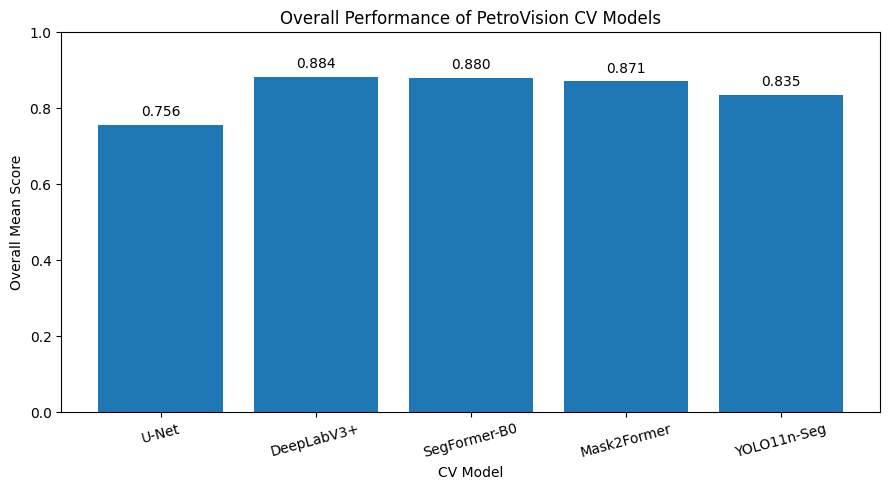

Saved: /content/drive/MyDrive/PetroVision/results/cv_overall_performance.png


In [78]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load master CV summary
# --------------------------------------------------

summary_path = Path(
    "/content/drive/MyDrive/PetroVision/results/"
    "cv_master_summary.json"
)

with open(summary_path, "r") as f:
    summary = json.load(f)

# --------------------------------------------------
# Extract overall mean scores
# --------------------------------------------------

rows = []

for model_name, model_data in summary["models"].items():
    rows.append({
        "Model": model_name,
        "Overall Mean": model_data["overall_mean_metric"]
    })

df = pd.DataFrame(rows)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(9, 5))

bars = plt.bar(
    df["Model"],
    df["Overall Mean"]
)

plt.ylabel("Overall Mean Score")
plt.xlabel("CV Model")
plt.title("Overall Performance of PetroVision CV Models")

plt.ylim(0, 1)

plt.xticks(rotation=15)

# Add exact values
for bar, value in zip(bars, df["Overall Mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

# --------------------------------------------------
# Save
# --------------------------------------------------

output_path = Path(
    "/content/drive/MyDrive/PetroVision/results/"
    "cv_overall_performance.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {output_path}")